# Looming animal response analysis - primary 2026 dataset

This notebook analyzes `CLfull...` looming stimuli in the primary 2026 animal file. It now follows the legacy loom-analysis behavior: fixed onset frame within each CL block, legacy rotation of both animal and stimulus coordinates, actual trajectory plots, and legacy baseline/response escape metrics.

In [7]:
#Set code folder
import os
codeDir = 'C:/Users/crodri19/larschpostdoc_analyses/selection_shoaling/jlsocialbehavior/' #adapt this to your code folder
os.chdir(codeDir)


from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from functions.joh_loom_helpers import (
    embedded_stimulus_from_animal_file,
    extract_legacy_loom_snippets,
    legacy_loom_response_metrics,
    load_animal_file,
    loom_trials,
    stimulus_blocks,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

In [8]:
animal_path = Path(r"C:\Users\crodri19\larschpostdoc_analyses\data\PositionTxt_allROI2026-06-26T10_35_06.csv")

animals = load_animal_file(animal_path)
stimulus = embedded_stimulus_from_animal_file(animals)
blocks = stimulus_blocks(stimulus)
trials = loom_trials(stimulus)

LEGACY_ONSET_IN_BLOCK = 150
PRE_FRAMES = 50
POST_FRAMES = 99
TRAJECTORY_START_FRAME = 1
TRAJECTORY_END_FRAME = 49

animals.shape, stimulus.shape, trials.shape

((469252, 109), (469252, 7), (68, 10))

## Trial-specific orientation grid

Plot raw fish orientation during a selected CL episode. Edit the parameters at the top of the next cell to switch loom size, side, condition repeat, or episode-frame window.

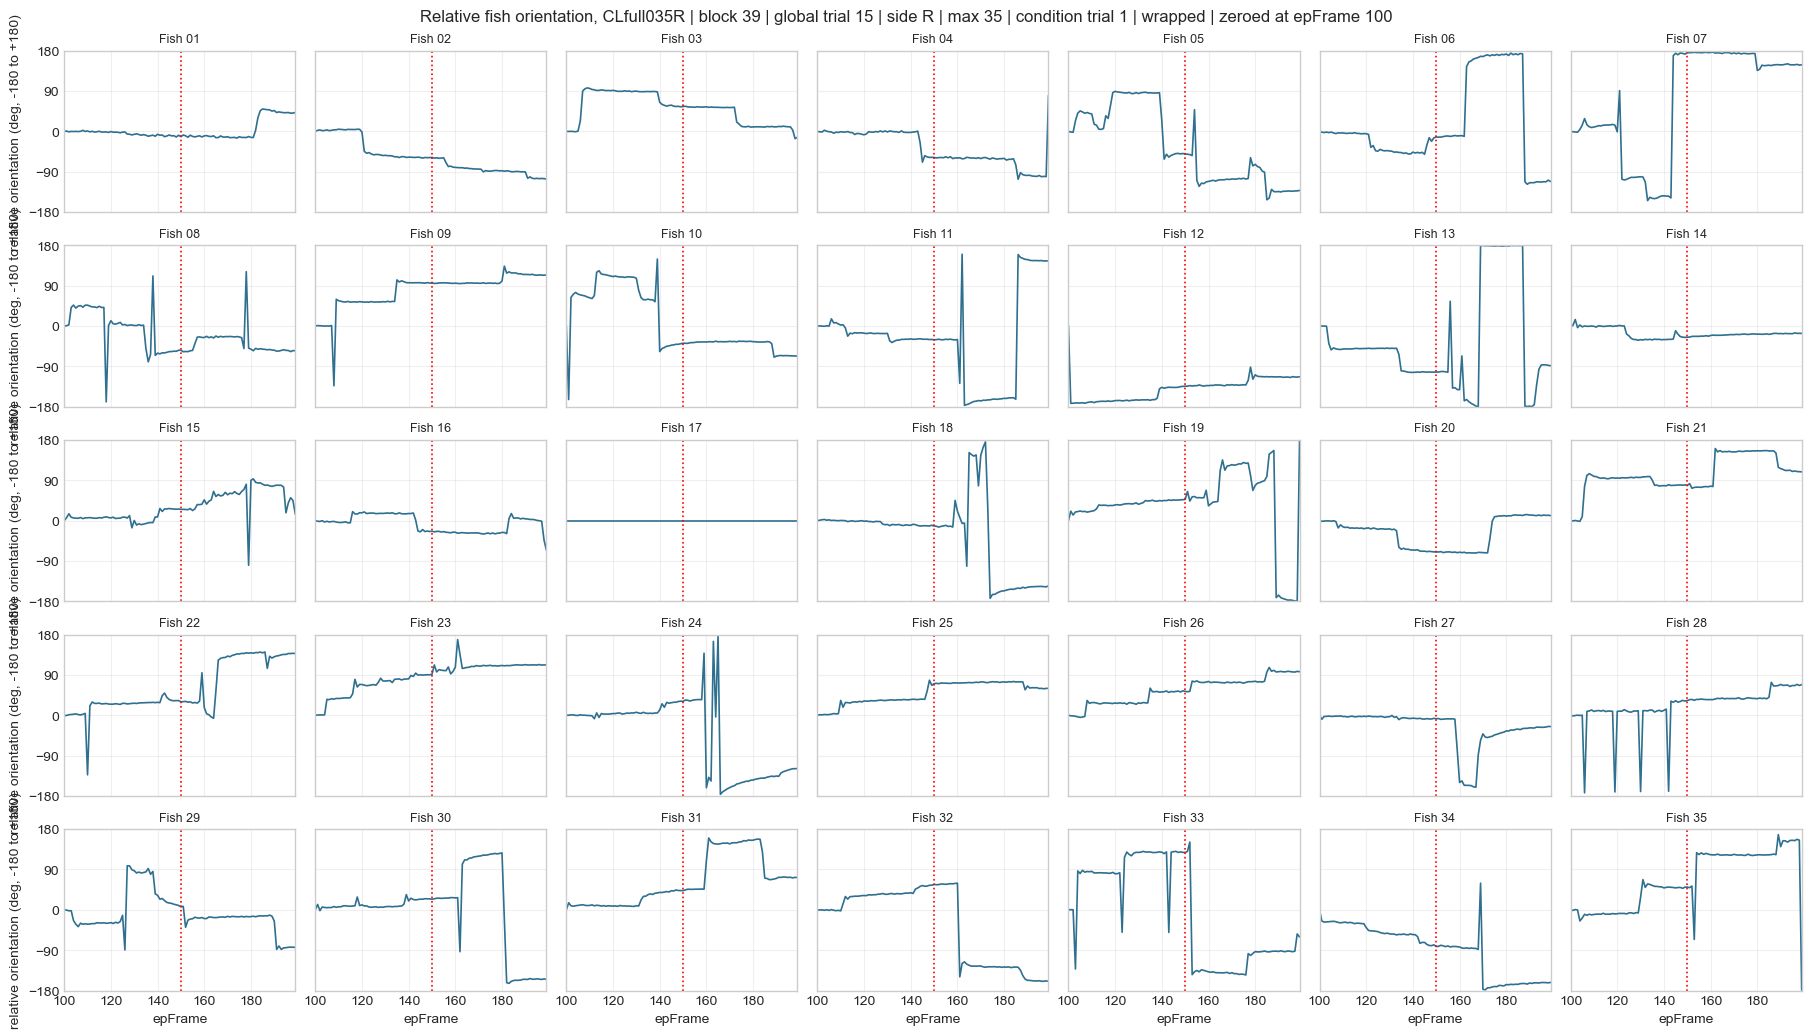

In [9]:
ORIENTATION_LOOM_MAX_SIZE = 35
ORIENTATION_SIDE = "R"
ORIENTATION_CONDITION_TRIAL = 1
ORIENTATION_FRAME_START = 100
ORIENTATION_FRAME_END = 199
ORIENTATION_WRAP_MODE = "wrapped"  # "wrapped" or "unwrapped"

# Orientation source and processing:
# - Values come directly from the raw animal_XX_orientation columns loaded from the animal trajectory file.
# - The raw values are stored in radians and are not legacy-rotated or transformed into egocentric coordinates here.
# - This plot converts radians to degrees, optionally unwraps the trace through time, and then subtracts
#   each fish's first orientation in the selected frame window so every trace starts at 0 degrees.
# - In wrapped mode, the relative orientation is shown as signed degrees from -180 to +180.


def plot_trial_orientation_grid(
    animal_df,
    trials_df,
    loom_max_size=ORIENTATION_LOOM_MAX_SIZE,
    side=ORIENTATION_SIDE,
    condition_trial=ORIENTATION_CONDITION_TRIAL,
    frame_start=ORIENTATION_FRAME_START,
    frame_end=ORIENTATION_FRAME_END,
    wrap_mode=ORIENTATION_WRAP_MODE,
    n_animals=35,
):
    if condition_trial < 1:
        raise ValueError("condition_trial is one-based and must be at least 1.")
    if frame_end < frame_start:
        raise ValueError("frame_end must be greater than or equal to frame_start.")
    if wrap_mode not in {"wrapped", "unwrapped"}:
        raise ValueError("wrap_mode must be either 'wrapped' or 'unwrapped'.")

    matching_trials = (
        trials_df.loc[trials_df["loom_max_size"].eq(loom_max_size) & trials_df["side"].eq(side)]
        .sort_values("trial")
        .reset_index(drop=True)
    )
    if matching_trials.empty:
        available = trials_df.groupby(["loom_max_size", "side"]).size().reset_index(name="n_trials")
        raise ValueError(
            f"No CL trials found for loom_max_size={loom_max_size!r}, side={side!r}.\n"
            f"Available conditions:\n{available.to_string(index=False)}"
        )
    if condition_trial > len(matching_trials):
        raise ValueError(
            f"Requested condition_trial={condition_trial}, but only {len(matching_trials)} "
            f"trial(s) exist for loom_max_size={loom_max_size!r}, side={side!r}."
        )

    trial_row = matching_trials.iloc[condition_trial - 1]
    block_start = int(trial_row["block_start_frame"])
    block_end = int(trial_row["block_end_frame"])
    start = block_start + frame_start
    stop = block_start + frame_end + 1

    if start < block_start or stop - 1 > block_end or stop > len(animal_df):
        raise ValueError(
            f"Requested epFrame {frame_start}..{frame_end} is outside selected block "
            f"range 0..{block_end - block_start} for block {int(trial_row['block'])}."
        )

    orientation_cols = [f"animal_{animal:02d}_orientation" for animal in range(1, n_animals + 1)]
    missing_cols = [col for col in orientation_cols if col not in animal_df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected orientation columns: {missing_cols}")

    ep_frames = np.arange(frame_start, frame_end + 1)
    orientation_rad = animal_df.iloc[start:stop][orientation_cols].to_numpy(dtype=float)
    if wrap_mode == "wrapped":
        raw_orientation_deg = np.mod(np.degrees(orientation_rad), 360)
        orientation_deg = (raw_orientation_deg - raw_orientation_deg[0, :] + 180) % 360 - 180
        y_label = "relative orientation (deg, -180 to +180)"
    else:
        raw_orientation_deg = np.degrees(np.unwrap(orientation_rad, axis=0))
        orientation_deg = raw_orientation_deg - raw_orientation_deg[0, :]
        y_label = "relative unwrapped orientation (deg)"

    fig, axes = plt.subplots(5, 7, figsize=(18, 10), sharex=True, sharey=True, constrained_layout=True)
    for animal_index, ax in enumerate(axes.flat, start=1):
        ax.plot(ep_frames, orientation_deg[:, animal_index - 1], color="#2f6f8f", lw=1.2)
        if frame_start <= 150 <= frame_end:
            ax.axvline(150, color="red", linestyle=":", lw=1.2)
        ax.set_title(f"Fish {animal_index:02d}", fontsize=9)
        ax.set_xlim(frame_start, frame_end)
        if wrap_mode == "wrapped":
            ax.set_ylim(-180, 180)
            ax.set_yticks([-180, -90, 0, 90, 180])
        else:
            ax.margins(y=0.08)
        ax.grid(True, alpha=0.3)
        if (animal_index - 1) % 7 == 0:
            ax.set_ylabel(y_label)
        if animal_index > 28:
            ax.set_xlabel("epFrame")

    fig.suptitle(
        f"Relative fish orientation, {trial_row['episode']} | block {int(trial_row['block'])} | "
        f"global trial {int(trial_row['trial'])} | side {trial_row['side']} | "
        f"max {int(trial_row['loom_max_size'])} | condition trial {condition_trial} | "
        f"{wrap_mode} | zeroed at epFrame {frame_start}",
        y=1.02,
    )
    return fig, axes, trial_row


orientation_fig, orientation_axes, selected_orientation_trial = plot_trial_orientation_grid(animals, trials)
plt.show()

## Linear and angular velocity during CL episodes

Compute 30-frame linear and angular velocity windows from the start of each selected CL block through epFrame 300. The red dotted line marks the stimulus presentation frame at epFrame 150.

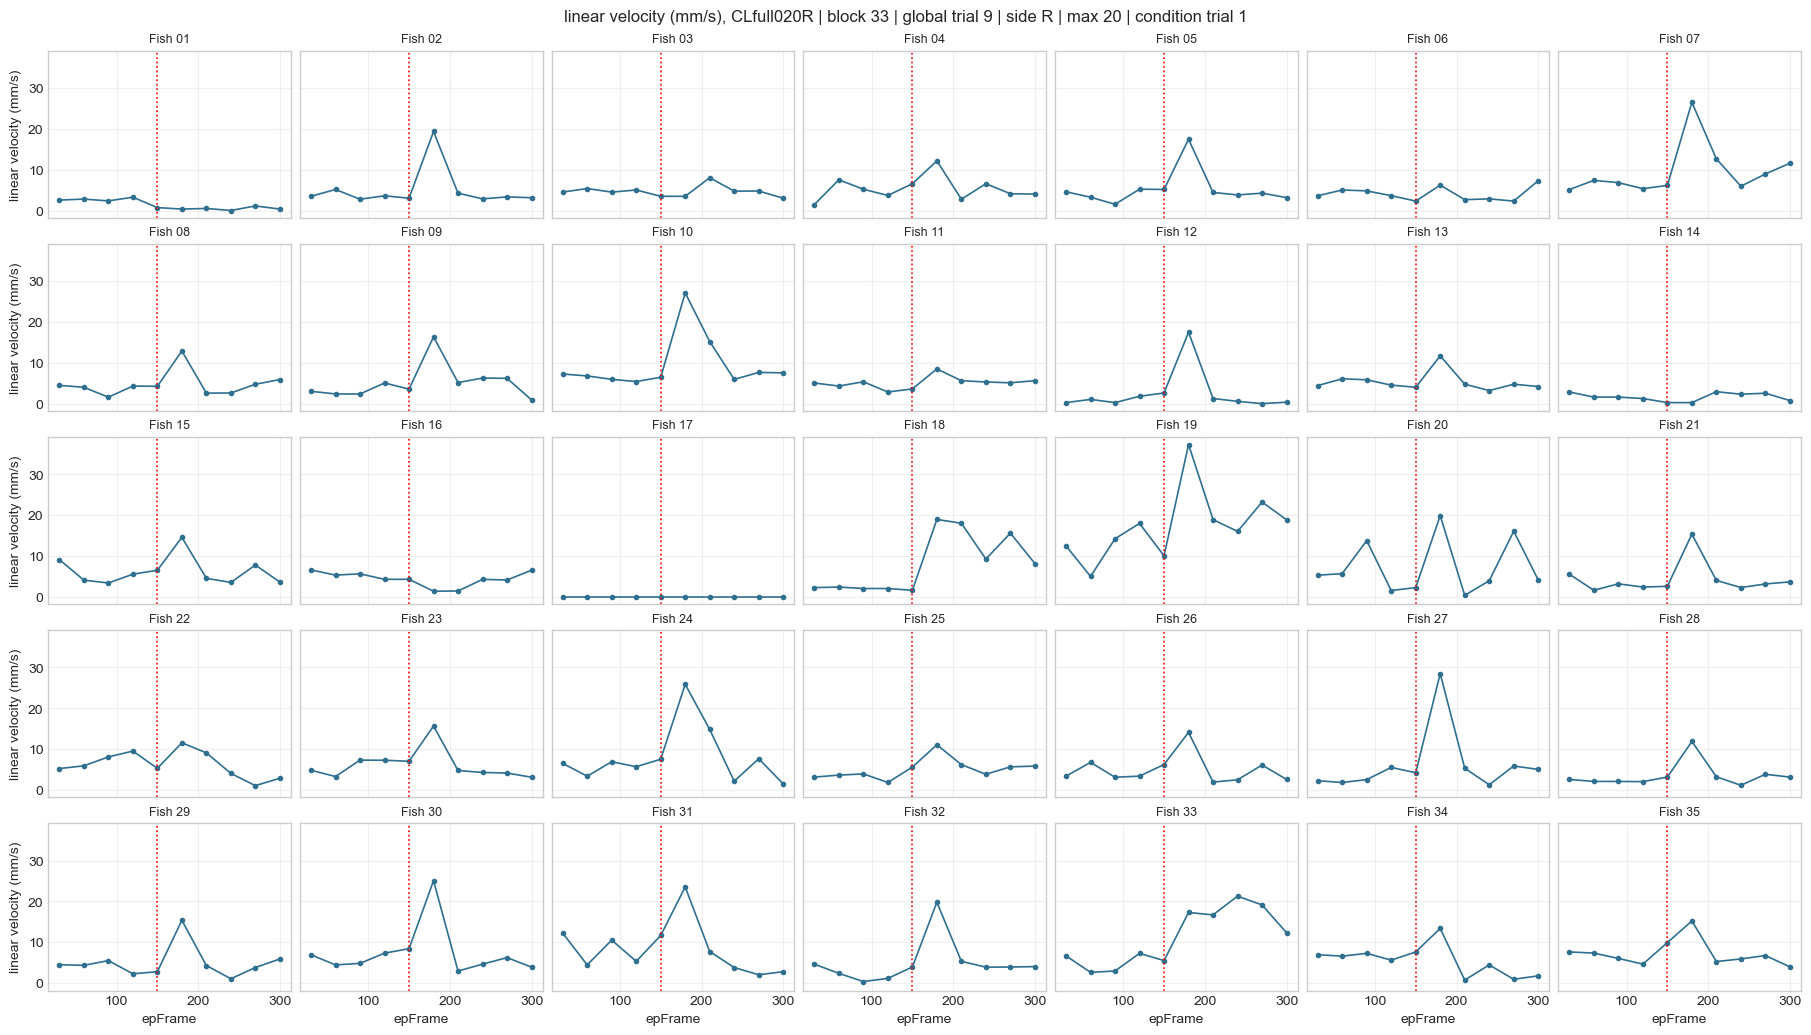

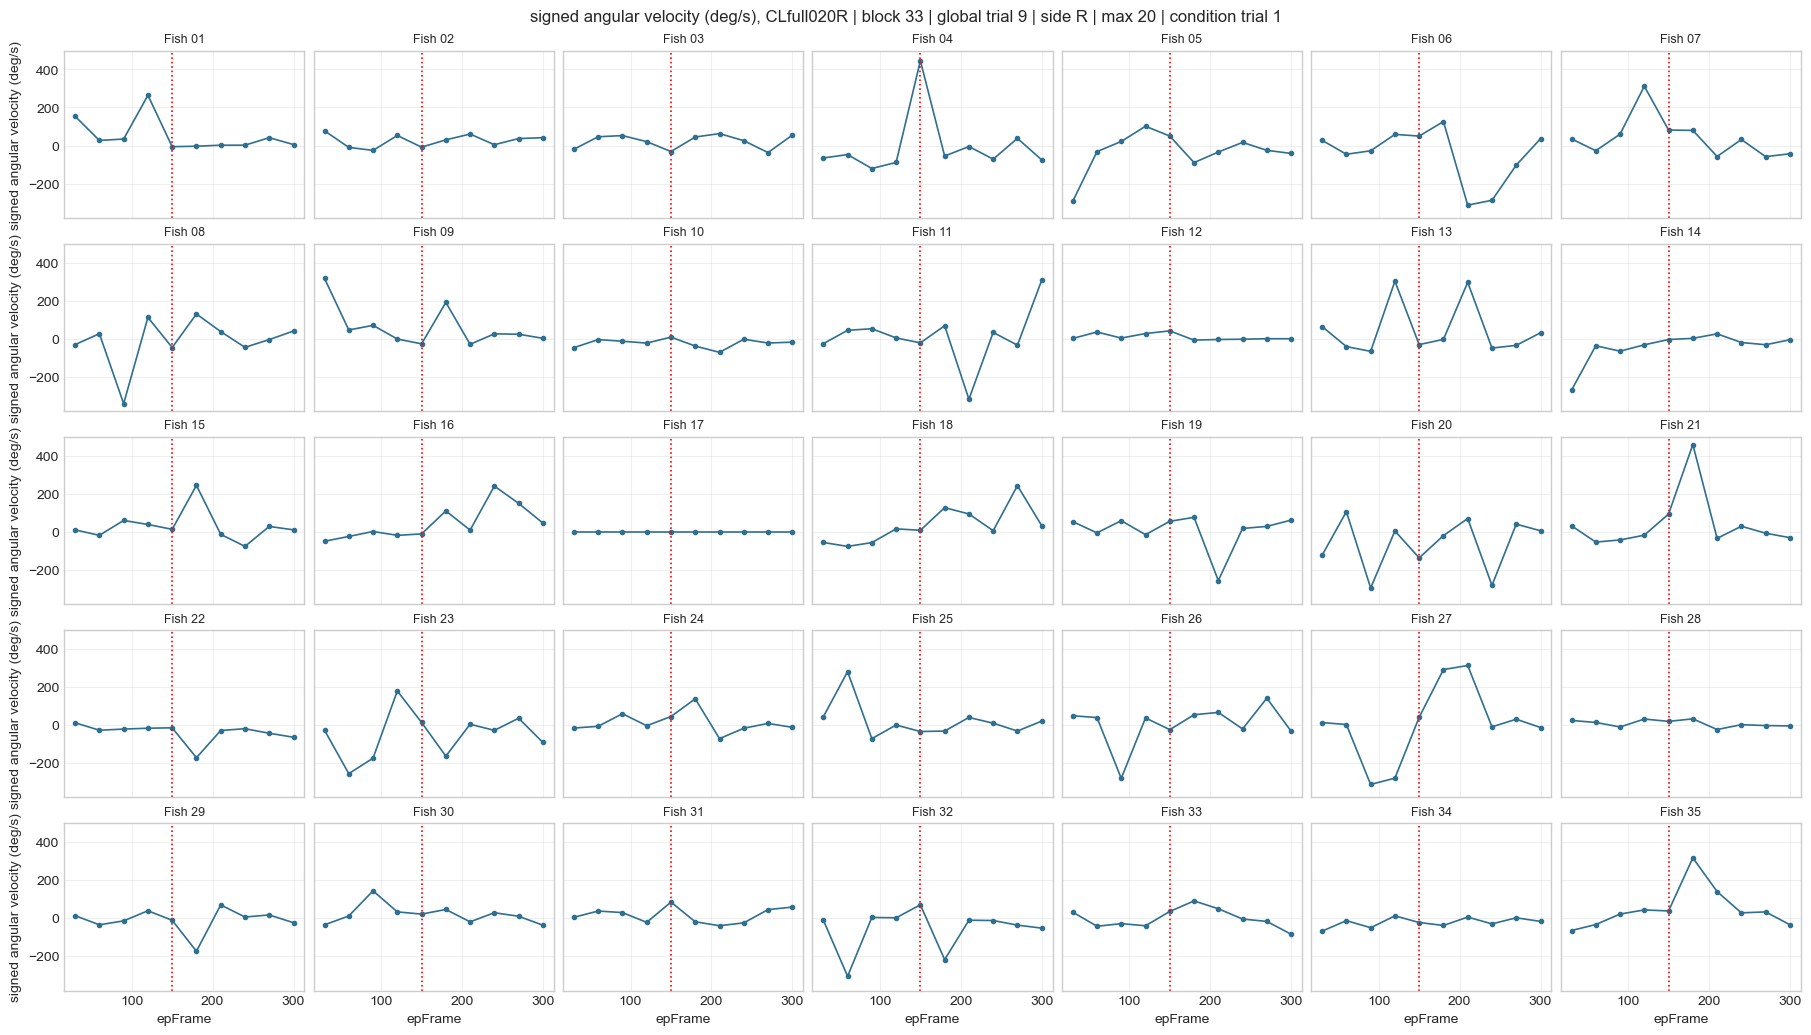

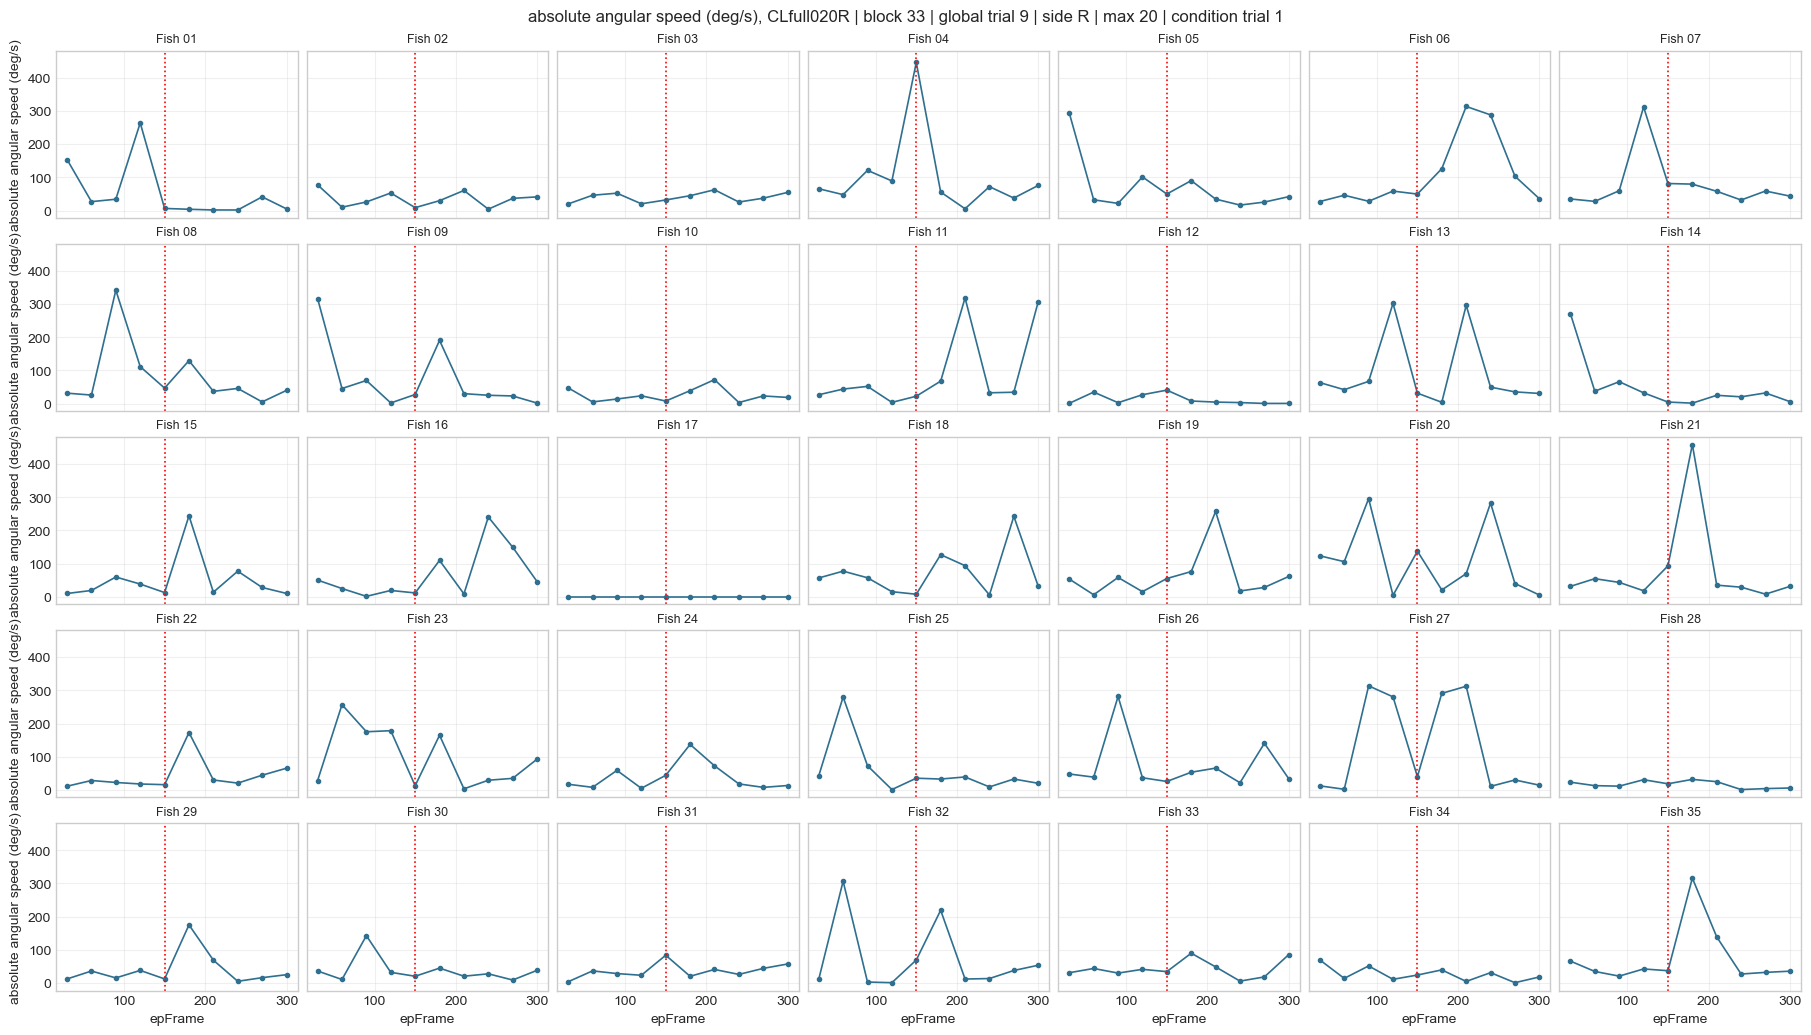

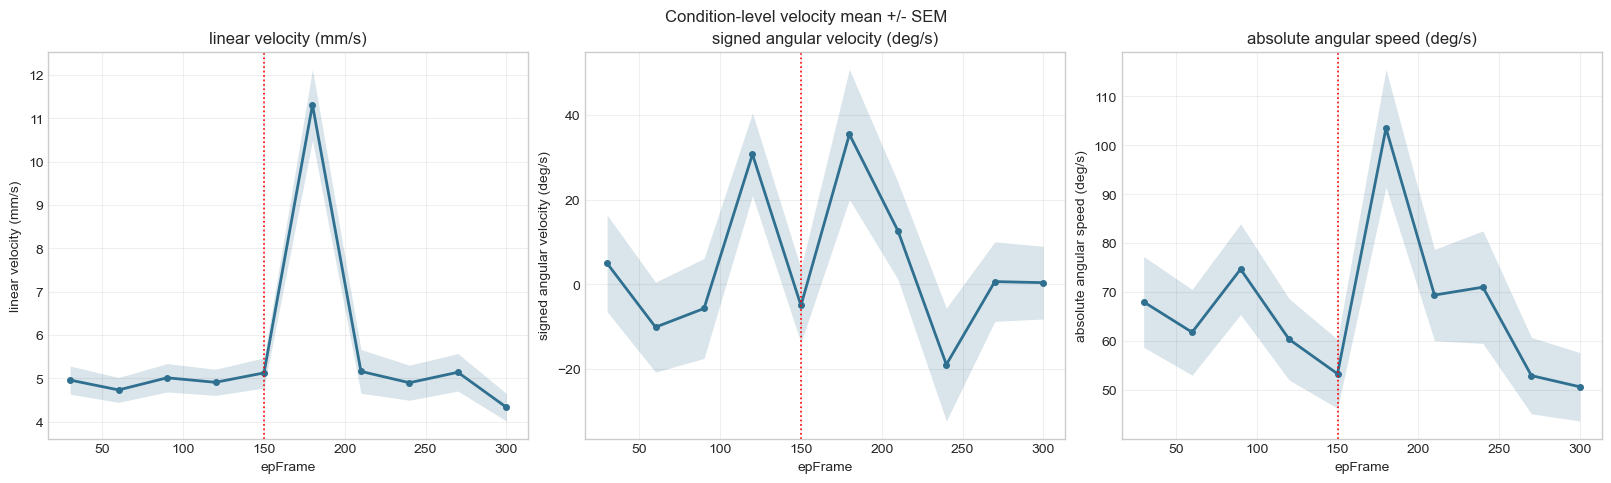

,period,metric,mean,sem,n_trial_animals
0,baseline,linear velocity (mm/s),4.903470,0.249526,105
1,baseline,signed angular velocity (deg/s),4.976250,5.613903,105
2,baseline,absolute angular speed (deg/s),66.182806,4.923349,105
3,post_stimulus,linear velocity (mm/s),6.168752,0.366395,105
4,post_stimulus,signed angular velocity (deg/s),6.047371,4.979982,105
5,post_stimulus,absolute angular speed (deg/s),69.473108,5.269271,105


In [10]:
VELOCITY_LOOM_MAX_SIZE = 20
VELOCITY_SIDE = "R"
VELOCITY_CONDITION_TRIAL = 1
VELOCITY_FRAME_START = 0
VELOCITY_FRAME_END = 300
VELOCITY_STIMULUS_FRAME = 150
VELOCITY_STEP_FRAMES = 30
VELOCITY_FPS = 30
VELOCITY_UNITS_PER_MM = 4.0

# Velocity source and processing:
# - x, y, and orientation are read directly from the raw animal_XX_x, animal_XX_y,
#   and animal_XX_orientation columns loaded from the animal trajectory file.
# - No egocentric rotation, legacy coordinate transform, or L/R mirroring is applied here.
# - Linear velocity is computed from raw x/y displacement over each 30-frame window,
#   converted to mm/s using VELOCITY_UNITS_PER_MM and VELOCITY_FPS.
# - Angular velocity uses unwrapped raw orientation through time, so crossings near
#   0/360 degrees do not create artificial jumps.


VELOCITY_METRICS = {
    "linear_velocity_mm_s": "linear velocity (mm/s)",
    "signed_angular_velocity_deg_s": "signed angular velocity (deg/s)",
    "absolute_angular_speed_deg_s": "absolute angular speed (deg/s)",
}


def extract_velocity_metrics(
    animal_df,
    trials_df,
    loom_max_size=VELOCITY_LOOM_MAX_SIZE,
    side=VELOCITY_SIDE,
    frame_start=VELOCITY_FRAME_START,
    frame_end=VELOCITY_FRAME_END,
    step_frames=VELOCITY_STEP_FRAMES,
    fps=VELOCITY_FPS,
    units_per_mm=VELOCITY_UNITS_PER_MM,
    n_animals=35,
):
    if frame_start < 0:
        raise ValueError("frame_start must be at least 0.")
    if frame_end <= frame_start:
        raise ValueError("frame_end must be greater than frame_start.")
    if step_frames <= 0:
        raise ValueError("step_frames must be greater than 0.")
    if fps <= 0:
        raise ValueError("fps must be greater than 0.")
    if units_per_mm <= 0:
        raise ValueError("units_per_mm must be greater than 0.")

    matching_trials = (
        trials_df.loc[trials_df["loom_max_size"].eq(loom_max_size) & trials_df["side"].eq(side)]
        .sort_values("trial")
        .reset_index(drop=True)
    )
    if matching_trials.empty:
        available = trials_df.groupby(["loom_max_size", "side"]).size().reset_index(name="n_trials")
        raise ValueError(
            f"No CL trials found for loom_max_size={loom_max_size!r}, side={side!r}.\n"
            f"Available conditions:\n{available.to_string(index=False)}"
        )

    x_cols = [f"animal_{animal:02d}_x" for animal in range(1, n_animals + 1)]
    y_cols = [f"animal_{animal:02d}_y" for animal in range(1, n_animals + 1)]
    orientation_cols = [f"animal_{animal:02d}_orientation" for animal in range(1, n_animals + 1)]
    missing_cols = [col for col in x_cols + y_cols + orientation_cols if col not in animal_df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected animal columns: {missing_cols}")

    sample_frames = np.arange(frame_start + step_frames, frame_end + 1, step_frames)
    if len(sample_frames) == 0:
        raise ValueError("No velocity sample frames fit inside the requested window.")
    seconds = step_frames / fps
    rows = []

    for condition_trial, trial_row in enumerate(matching_trials.itertuples(index=False), start=1):
        block_start = int(trial_row.block_start_frame)
        block_end = int(trial_row.block_end_frame)
        start = block_start + frame_start
        stop = block_start + frame_end + 1
        if start < block_start or stop - 1 > block_end or stop > len(animal_df):
            raise ValueError(
                f"Requested epFrame {frame_start}..{frame_end} is outside block range "
                f"0..{block_end - block_start} for block {int(trial_row.block)}."
            )

        x_window = animal_df.iloc[start:stop][x_cols].to_numpy(dtype=float)
        y_window = animal_df.iloc[start:stop][y_cols].to_numpy(dtype=float)
        orientation_window = animal_df.iloc[start:stop][orientation_cols].to_numpy(dtype=float)
        unwrapped_orientation = np.unwrap(orientation_window, axis=0)

        for ep_frame in sample_frames:
            current_index = ep_frame - frame_start
            previous_index = current_index - step_frames
            dx = x_window[current_index] - x_window[previous_index]
            dy = y_window[current_index] - y_window[previous_index]
            linear_velocity = np.hypot(dx, dy) / units_per_mm / seconds
            angular_velocity = np.degrees(
                unwrapped_orientation[current_index] - unwrapped_orientation[previous_index]
            ) / seconds

            for animal_index in range(n_animals):
                rows.append(
                    {
                        "trial": int(trial_row.trial),
                        "condition_trial": condition_trial,
                        "block": int(trial_row.block),
                        "episode": trial_row.episode,
                        "side": trial_row.side,
                        "loom_max_size": int(trial_row.loom_max_size),
                        "animal": animal_index + 1,
                        "window_start_epFrame": int(ep_frame - step_frames),
                        "epFrame": int(ep_frame),
                        "global_frame": int(block_start + ep_frame),
                        "linear_velocity_mm_s": linear_velocity[animal_index],
                        "signed_angular_velocity_deg_s": angular_velocity[animal_index],
                        "absolute_angular_speed_deg_s": abs(angular_velocity[animal_index]),
                    }
                )

    return pd.DataFrame(rows)


def plot_individual_velocity_grid(
    velocity_df,
    metric,
    ylabel,
    condition_trial=VELOCITY_CONDITION_TRIAL,
    stimulus_frame=VELOCITY_STIMULUS_FRAME,
    n_animals=35,
):
    selected = velocity_df.loc[velocity_df["condition_trial"].eq(condition_trial)]
    if selected.empty:
        available = sorted(velocity_df["condition_trial"].unique())
        raise ValueError(f"condition_trial={condition_trial} not found. Available condition trials: {available}")

    trial_meta = selected.iloc[0]
    fig, axes = plt.subplots(5, 7, figsize=(18, 10), sharex=True, sharey=True, constrained_layout=True)
    for animal_index, ax in enumerate(axes.flat, start=1):
        trace = selected.loc[selected["animal"].eq(animal_index)].sort_values("epFrame")
        ax.plot(trace["epFrame"], trace[metric], color="#2f6f8f", marker="o", ms=3, lw=1.2)
        ax.axvline(stimulus_frame, color="red", linestyle=":", lw=1.2)
        ax.set_title(f"Fish {animal_index:02d}", fontsize=9)
        ax.grid(True, alpha=0.3)
        if (animal_index - 1) % 7 == 0:
            ax.set_ylabel(ylabel)
        if animal_index > 28:
            ax.set_xlabel("epFrame")

    fig.suptitle(
        f"{ylabel}, {trial_meta['episode']} | block {int(trial_meta['block'])} | "
        f"global trial {int(trial_meta['trial'])} | side {trial_meta['side']} | "
        f"max {int(trial_meta['loom_max_size'])} | condition trial {condition_trial}",
        y=1.02,
    )
    return fig, axes


def summarize_velocity_condition(velocity_df, metrics=VELOCITY_METRICS):
    group = velocity_df.groupby("epFrame", as_index=False)
    means = group[list(metrics)].mean().rename(columns={metric: f"{metric}_mean" for metric in metrics})
    sems = group[list(metrics)].sem().rename(columns={metric: f"{metric}_sem" for metric in metrics})
    return means.merge(sems, on="epFrame")


def plot_velocity_condition_summary(
    summary_df,
    metrics=VELOCITY_METRICS,
    stimulus_frame=VELOCITY_STIMULUS_FRAME,
):
    fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4.5), sharex=True, constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, (metric, ylabel) in zip(axes, metrics.items()):
        x = summary_df["epFrame"].to_numpy(dtype=float)
        mean = summary_df[f"{metric}_mean"].to_numpy(dtype=float)
        sem = summary_df[f"{metric}_sem"].to_numpy(dtype=float)
        ax.plot(x, mean, color="#2f6f8f", marker="o", ms=4, lw=2)
        ax.fill_between(x, mean - sem, mean + sem, color="#2f6f8f", alpha=0.18, lw=0)
        ax.axvline(stimulus_frame, color="red", linestyle=":", lw=1.2)
        ax.set_xlabel("epFrame")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.grid(True, alpha=0.3)

    fig.suptitle("Condition-level velocity mean +/- SEM", y=1.04)
    return fig, axes


def summarize_velocity_prepost(
    velocity_df,
    stimulus_frame=VELOCITY_STIMULUS_FRAME,
    metrics=VELOCITY_METRICS,
):
    labeled = velocity_df.copy()
    labeled["period"] = np.select(
        [labeled["epFrame"].lt(stimulus_frame), labeled["epFrame"].gt(stimulus_frame)],
        ["baseline", "post_stimulus"],
        default="stimulus_window",
    )
    period_values = (
        labeled.loc[labeled["period"].ne("stimulus_window")]
        .groupby(["trial", "condition_trial", "animal", "period"], as_index=False)[list(metrics)]
        .mean()
    )

    rows = []
    for period in ["baseline", "post_stimulus"]:
        subset = period_values.loc[period_values["period"].eq(period)]
        for metric, label in metrics.items():
            values = subset[metric].to_numpy(dtype=float)
            finite_values = values[np.isfinite(values)]
            rows.append(
                {
                    "period": period,
                    "metric": label,
                    "mean": np.nanmean(finite_values) if len(finite_values) else np.nan,
                    "sem": np.nanstd(finite_values, ddof=1) / np.sqrt(len(finite_values)) if len(finite_values) > 1 else np.nan,
                    "n_trial_animals": len(finite_values),
                }
            )
    return pd.DataFrame(rows)


velocity_data = extract_velocity_metrics(animals, trials)
velocity_summary = summarize_velocity_condition(velocity_data)
velocity_prepost_summary = summarize_velocity_prepost(velocity_data)

for metric, ylabel in VELOCITY_METRICS.items():
    fig, axes = plot_individual_velocity_grid(velocity_data, metric, ylabel)
    plt.show()

velocity_summary_fig, velocity_summary_axes = plot_velocity_condition_summary(velocity_summary)
plt.show()

display(velocity_prepost_summary)


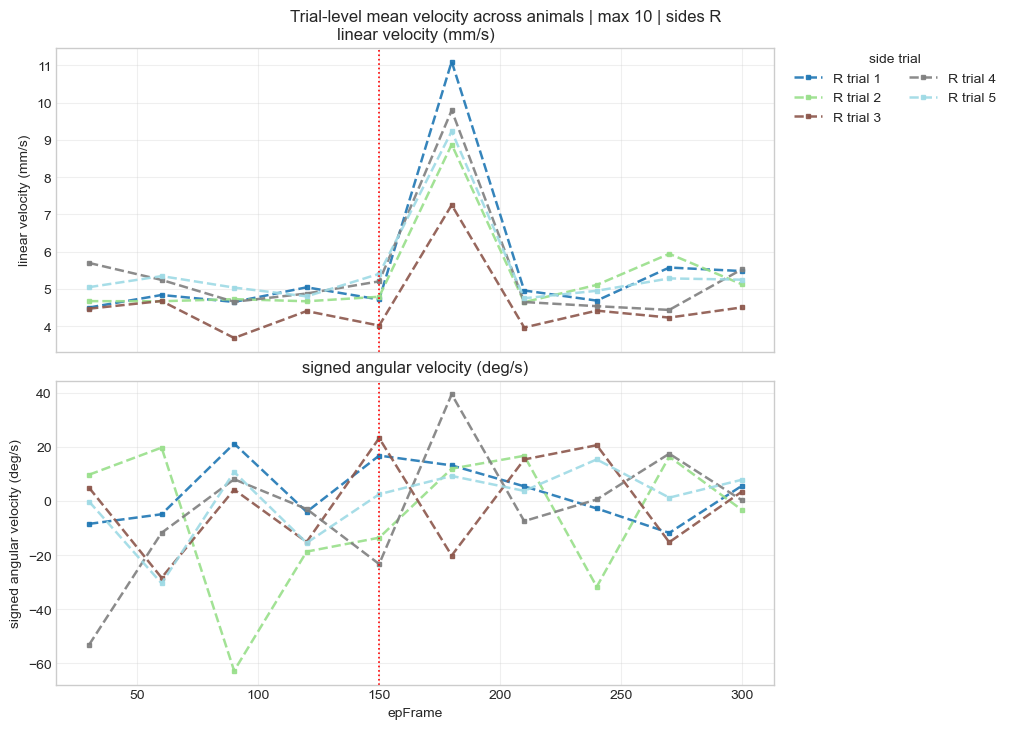

In [11]:
TRIAL_AVG_VELOCITY_LOOM_MAX_SIZE = 10 # default = VELOCITY_LOOM_MAX_SIZE
TRIAL_AVG_VELOCITY_SIDES = "R" # choose "L", "R" or ("L", "R")


TRIAL_AVG_VELOCITY_METRICS = {
    "linear_velocity_mm_s": "linear velocity (mm/s)",
    "signed_angular_velocity_deg_s": "signed angular velocity (deg/s)",
}


def plot_trial_average_velocity_lines(
    animal_df,
    trials_df,
    loom_max_size=TRIAL_AVG_VELOCITY_LOOM_MAX_SIZE,
    sides=TRIAL_AVG_VELOCITY_SIDES,
    metrics=TRIAL_AVG_VELOCITY_METRICS,
    stimulus_frame=VELOCITY_STIMULUS_FRAME,
):
    side_velocity_frames = []
    for side in sides:
        side_velocity_frames.append(
            extract_velocity_metrics(
                animal_df,
                trials_df,
                loom_max_size=loom_max_size,
                side=side,
            )
        )
    condition_velocity = pd.concat(side_velocity_frames, ignore_index=True)
    trial_average = (
        condition_velocity.groupby(
            ["trial", "condition_trial", "block", "episode", "side", "loom_max_size", "epFrame"],
            as_index=False,
        )[list(metrics)]
        .mean()
        .sort_values(["side", "condition_trial", "epFrame"])
    )

    line_keys = (
        trial_average[["side", "condition_trial"]]
        .drop_duplicates()
        .sort_values(["side", "condition_trial"])
        .reset_index(drop=True)
    )
    colors = plt.cm.tab20(np.linspace(0.02, 0.98, len(line_keys)))
    linestyles = {"L": "-", "R": "--"}
    markers = {"L": "o", "R": "s"}
    fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 7), sharex=True, constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, (metric, ylabel) in zip(axes, metrics.items()):
        for line_index, line_meta in line_keys.iterrows():
            side = line_meta["side"]
            condition_trial = int(line_meta["condition_trial"])
            trace = trial_average.loc[
                trial_average["side"].eq(side)
                & trial_average["condition_trial"].eq(condition_trial)
            ].sort_values("epFrame")
            ax.plot(
                trace["epFrame"],
                trace[metric],
                color=colors[line_index],
                linestyle=linestyles.get(side, "-"),
                marker=markers.get(side, "o"),
                ms=3,
                lw=1.8,
                alpha=0.9,
                label=f"{side} trial {condition_trial}",
            )
        ax.axvline(stimulus_frame, color="red", linestyle=":", lw=1.2)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("epFrame")
    axes[0].legend(
        title="side trial",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        ncol=2,
    )
    fig.suptitle(
        f"Trial-level mean velocity across animals | max {loom_max_size} | sides {'/'.join(sides)}",
        y=1.02,
    )
    return fig, axes, trial_average, condition_velocity


trial_avg_velocity_fig, trial_avg_velocity_axes, trial_avg_velocity, trial_avg_velocity_data = plot_trial_average_velocity_lines(
    animals,
    trials,
)
plt.show()


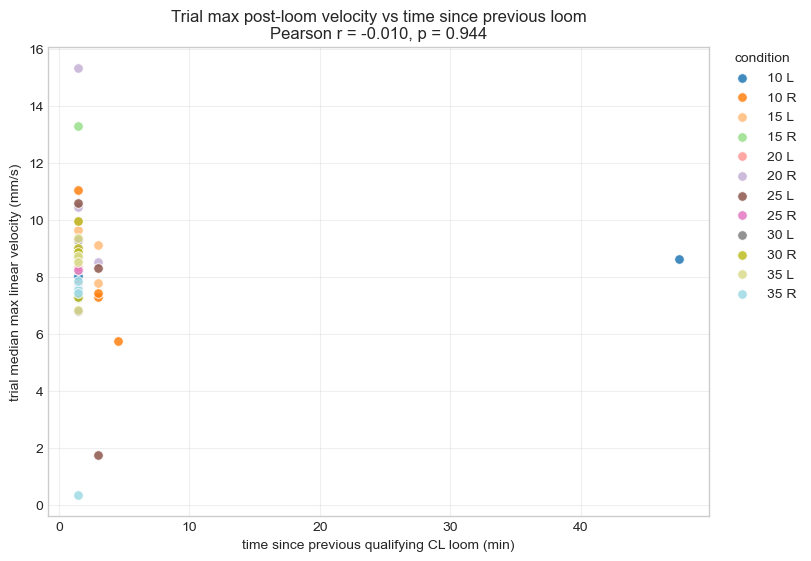

,trial,block,episode,side,loom_max_size,condition,fixed_loom_onset_frame,previous_fixed_loom_onset_frame,time_since_previous_loom_s,time_since_previous_loom_min,time_since_experiment_start_s,time_since_experiment_start_min,trial_mean_max_linear_velocity_mm_s,n_fish
0,5,29,CLfull010R,R,10,10 R,229650,226950.0,90.0,1.5,7655.0,127.583333,11.067972,35
1,6,30,CLfull015L,L,15,15 L,232350,229650.0,90.0,1.5,7745.0,129.083333,9.659840,35
2,7,31,CLfull015R,R,15,15 R,235050,232350.0,90.0,1.5,7835.0,130.583333,13.313527,35
3,8,32,CLfull020L,L,20,20 L,237750,235050.0,90.0,1.5,7925.0,132.083333,9.300538,35
4,9,33,CLfull020R,R,20,20 R,240450,237750.0,90.0,1.5,8015.0,133.583333,15.323593,35
5,10,34,CLfull025L,L,25,25 L,243150,240450.0,90.0,1.5,8105.0,135.083333,10.609548,35
6,11,35,CLfull025R,R,25,25 R,245850,243150.0,90.0,1.5,8195.0,136.583333,8.253787,35
7,12,36,CLfull030L,L,30,30 L,248550,245850.0,90.0,1.5,8285.0,138.083333,8.620470,35
8,13,37,CLfull030R,R,30,30 R,251250,248550.0,90.0,1.5,8375.0,139.583333,9.013878,35
9,14,38,CLfull035L,L,35,35 L,253950,251250.0,90.0,1.5,8465.0,141.083333,9.384162,35


In [12]:
# User-editable analysis settings. The 120-frame window spans 4 seconds at 30 fps.
# The max-size threshold keeps the same exclusion rule as the original analysis.
MAX_LOOM_SIZE_EXCLUDE_THRESHOLD = 5
TRIAL_MAX_VELOCITY_WINDOW_FRAMES = 120


def _trial_max_velocity_summary(
    animal_df,
    trials_df,
    max_loom_size_exclude_threshold,
    onset_in_block,
    window_frames,
    step_frames,
    fps,
    units_per_mm,
    n_animals,
    require_previous_loom,
):
    # The post-loom maximum is sampled in consecutive step_frames intervals.
    # Requiring an exact multiple prevents a partially filled final interval.
    if window_frames <= 0:
        raise ValueError("window_frames must be greater than 0.")
    if step_frames <= 0:
        raise ValueError("step_frames must be greater than 0.")
    if window_frames % step_frames != 0:
        raise ValueError("window_frames must be an exact multiple of step_frames.")
    if fps <= 0:
        raise ValueError("fps must be greater than 0.")
    if units_per_mm <= 0:
        raise ValueError("units_per_mm must be greater than 0.")

    # Each animal contributes raw x/y coordinates. No rotation, mirroring, or
    # egocentric transformation is applied because this analysis measures
    # screen-coordinate movement speed, matching the existing velocity analysis.
    x_cols = [f"animal_{animal:02d}_x" for animal in range(1, n_animals + 1)]
    y_cols = [f"animal_{animal:02d}_y" for animal in range(1, n_animals + 1)]
    missing_cols = [col for col in x_cols + y_cols if col not in animal_df.columns]
    if missing_cols:
        raise ValueError(f"Missing expected animal columns: {missing_cols}")

    # Sort by the actual block start so time is chronological even if trials_df
    # was assembled in a different order. Only looms above the threshold are
    # used, preserving the filtering of the original previous-loom analysis.
    ordered_trials = trials_df.sort_values("block_start_frame").reset_index(drop=True).copy()
    qualified_trials = ordered_trials.loc[
        ordered_trials["loom_max_size"].gt(max_loom_size_exclude_threshold)
    ].copy()

    # The legacy convention defines the loom onset as a fixed epFrame within
    # each block. This is also the reference point for the post-loom window.
    qualified_trials["fixed_loom_onset_frame"] = qualified_trials["block_start_frame"] + onset_in_block

    # Both x-axis variables are calculated from the same onset frame. The
    # experiment-start value is absolute time from global frame 0; the
    # previous-loom value compares consecutive qualifying looms only.
    qualified_trials["time_since_experiment_start_s"] = qualified_trials["fixed_loom_onset_frame"] / fps
    qualified_trials["time_since_experiment_start_min"] = qualified_trials["time_since_experiment_start_s"] / 60
    qualified_trials["previous_fixed_loom_onset_frame"] = qualified_trials["fixed_loom_onset_frame"].shift(1)
    qualified_trials["time_since_previous_loom_s"] = (
        qualified_trials["fixed_loom_onset_frame"] - qualified_trials["previous_fixed_loom_onset_frame"]
    ) / fps
    qualified_trials["time_since_previous_loom_min"] = qualified_trials["time_since_previous_loom_s"] / 60

    # The previous-loom correlation cannot use the first qualifying loom,
    # because it has no preceding qualifying loom. The experiment-start
    # correlation does include it because its absolute start time is defined.
    if require_previous_loom:
        included_trials = qualified_trials.loc[
            qualified_trials["previous_fixed_loom_onset_frame"].notna()
        ].copy()
    else:
        included_trials = qualified_trials.copy()

    # A 30-frame displacement is converted to mm/s, then the largest speed
    # across all intervals in the user-selected post-onset window is retained
    # for each animal. The plotted y value is the mean of those animal maxima.
    rows = []
    seconds = step_frames / fps
    sample_offsets = np.arange(step_frames, window_frames + 1, step_frames)

    for trial_row in included_trials.itertuples(index=False):
        onset = int(trial_row.fixed_loom_onset_frame)
        sample_frames = onset + sample_offsets

        # Skip trials whose block ends before the complete analysis window, or
        # whose requested global frames are outside the animal recording.
        if sample_frames[-1] > int(trial_row.block_end_frame) or sample_frames[-1] >= len(animal_df):
            continue

        fish_velocity_windows = []
        for sample_frame in sample_frames:
            previous_frame = int(sample_frame - step_frames)
            current_frame = int(sample_frame)
            dx = animal_df.loc[current_frame, x_cols].to_numpy(dtype=float) - animal_df.loc[previous_frame, x_cols].to_numpy(dtype=float)
            dy = animal_df.loc[current_frame, y_cols].to_numpy(dtype=float) - animal_df.loc[previous_frame, y_cols].to_numpy(dtype=float)
            fish_velocity_windows.append(np.hypot(dx, dy) / units_per_mm / seconds)

        fish_max_velocity = np.nanmax(np.vstack(fish_velocity_windows), axis=0)
        previous_onset = trial_row.previous_fixed_loom_onset_frame
        rows.append(
            {
                "trial": int(trial_row.trial),
                "block": int(trial_row.block),
                "episode": trial_row.episode,
                "side": trial_row.side,
                "loom_max_size": int(trial_row.loom_max_size),
                "condition": f"{int(trial_row.loom_max_size)} {trial_row.side}",
                "fixed_loom_onset_frame": onset,
                "previous_fixed_loom_onset_frame": float(previous_onset) if pd.notna(previous_onset) else np.nan,
                "time_since_previous_loom_s": float(trial_row.time_since_previous_loom_s) if pd.notna(trial_row.time_since_previous_loom_s) else np.nan,
                "time_since_previous_loom_min": float(trial_row.time_since_previous_loom_min) if pd.notna(trial_row.time_since_previous_loom_min) else np.nan,
                "time_since_experiment_start_s": float(trial_row.time_since_experiment_start_s),
                "time_since_experiment_start_min": float(trial_row.time_since_experiment_start_min),
                "trial_mean_max_linear_velocity_mm_s": float(np.nanmedian(fish_max_velocity)),
                "n_fish": int(np.isfinite(fish_max_velocity).sum()),
            }
        )

    return pd.DataFrame(rows).sort_values("fixed_loom_onset_frame").reset_index(drop=True)


def trial_max_velocity_vs_previous_loom(
    animal_df,
    trials_df,
    max_loom_size_exclude_threshold=MAX_LOOM_SIZE_EXCLUDE_THRESHOLD,
    onset_in_block=LEGACY_ONSET_IN_BLOCK,
    window_frames=TRIAL_MAX_VELOCITY_WINDOW_FRAMES,
    step_frames=VELOCITY_STEP_FRAMES,
    fps=VELOCITY_FPS,
    units_per_mm=VELOCITY_UNITS_PER_MM,
    n_animals=35,
):
    # Keep the previous-loom analysis as a small wrapper around the shared
    # extractor, while explicitly requiring a preceding qualifying loom.
    return _trial_max_velocity_summary(
        animal_df,
        trials_df,
        max_loom_size_exclude_threshold,
        onset_in_block,
        window_frames,
        step_frames,
        fps,
        units_per_mm,
        n_animals,
        require_previous_loom=True,
    )


def plot_trial_max_velocity_vs_previous_loom(trial_summary):
    # Each row is one loom trial. The y value is already the trial median of
    # per-animal maximum speeds measured during the selected post-loom window.
    if trial_summary.empty:
        raise ValueError("No trials remain after applying the max loom size threshold and previous-loom filter.")

    # Use a stable color for every loom-size/side condition so repeated trials
    # can be compared visually without changing the condition identity.
    conditions = (
        trial_summary[["loom_max_size", "side", "condition"]]
        .drop_duplicates()
        .sort_values(["loom_max_size", "side"])
        .reset_index(drop=True)
    )
    colors = plt.cm.tab20(np.linspace(0.02, 0.98, len(conditions)))
    condition_colors = dict(zip(conditions["condition"], colors))

    fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
    for condition in conditions["condition"]:
        subset = trial_summary.loc[trial_summary["condition"].eq(condition)]
        ax.scatter(
            subset["time_since_previous_loom_min"],
            subset["trial_mean_max_linear_velocity_mm_s"],
            color=condition_colors[condition],
            s=48,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.7,
            label=condition,
        )

    # Pearson correlation is calculated across all finite trial-level points
    # pooled across conditions. It is descriptive and does not control for
    # loom size or side; the colors show those condition labels separately.
    finite = trial_summary[["time_since_previous_loom_min", "trial_mean_max_linear_velocity_mm_s"]].dropna()
    title = "Trial max post-loom velocity vs time since previous loom"
    if len(finite) >= 3:
        try:
            from scipy.stats import pearsonr

            r_value, p_value = pearsonr(
                finite["time_since_previous_loom_min"],
                finite["trial_mean_max_linear_velocity_mm_s"],
            )
            title = f"{title}\nPearson r = {r_value:.3f}, p = {p_value:.3g}"
        except ImportError:
            r_value = finite["time_since_previous_loom_min"].corr(
                finite["trial_mean_max_linear_velocity_mm_s"]
            )
            title = f"{title}\nPearson r = {r_value:.3f}, p unavailable"

    ax.set_xlabel("time since previous qualifying CL loom (min)")
    ax.set_ylabel("trial median max linear velocity (mm/s)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(title="condition", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    return fig, ax


# Pass the editable window explicitly so changing the value above and rerunning
# this cell immediately recomputes the maximum speed and the correlation.
trial_max_velocity_summary = trial_max_velocity_vs_previous_loom(
    animals,
    trials,
    window_frames=TRIAL_MAX_VELOCITY_WINDOW_FRAMES,
)
trial_max_velocity_fig, trial_max_velocity_ax = plot_trial_max_velocity_vs_previous_loom(trial_max_velocity_summary)
plt.show()

display(trial_max_velocity_summary)


## Trial max post-loom velocity vs time since experiment start

This is the same trial-level maximum-speed analysis as the previous cell, but the x-axis is the fixed loom-onset time measured from global frame 0.

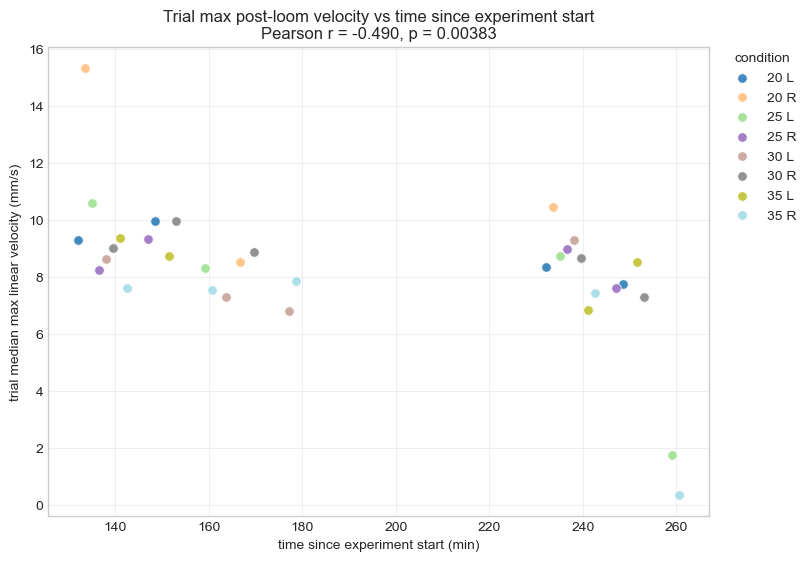

,trial,block,episode,side,loom_max_size,condition,fixed_loom_onset_frame,previous_fixed_loom_onset_frame,time_since_previous_loom_s,time_since_previous_loom_min,time_since_experiment_start_s,time_since_experiment_start_min,trial_mean_max_linear_velocity_mm_s,n_fish
0,8,32,CLfull020L,L,20,20 L,237750,NaN,NaN,NaN,7925.0,132.083333,9.300538,35
1,9,33,CLfull020R,R,20,20 R,240450,237750.0,90.0,1.5,8015.0,133.583333,15.323593,35
2,10,34,CLfull025L,L,25,25 L,243150,240450.0,90.0,1.5,8105.0,135.083333,10.609548,35
3,11,35,CLfull025R,R,25,25 R,245850,243150.0,90.0,1.5,8195.0,136.583333,8.253787,35
4,12,36,CLfull030L,L,30,30 L,248550,245850.0,90.0,1.5,8285.0,138.083333,8.620470,35
5,13,37,CLfull030R,R,30,30 R,251250,248550.0,90.0,1.5,8375.0,139.583333,9.013878,35
6,14,38,CLfull035L,L,35,35 L,253950,251250.0,90.0,1.5,8465.0,141.083333,9.384162,35
7,15,39,CLfull035R,R,35,35 R,256650,253950.0,90.0,1.5,8555.0,142.583333,7.603453,35
8,18,42,CLfull025R,R,25,25 R,264750,256650.0,270.0,4.5,8825.0,147.083333,9.334077,35
9,19,43,CLfull020L,L,20,20 L,267450,264750.0,90.0,1.5,8915.0,148.583333,9.953015,35


In [13]:
# User-editable setting for this correlation plot. At 30 fps, 120 frames = 4 seconds.
# This variable is intentionally local to the plotting cell so the analysis
# can be adjusted and rerun without changing the preceding velocity analysis.
TRIAL_MAX_VELOCITY_START_WINDOW_FRAMES = 120


MAX_LOOM_SIZE_EXCLUDE_THRESHOLD = 15


def trial_max_velocity_vs_experiment_start(
    animal_df,
    trials_df,
    max_loom_size_exclude_threshold=MAX_LOOM_SIZE_EXCLUDE_THRESHOLD,
    onset_in_block=LEGACY_ONSET_IN_BLOCK,
    window_frames=TRIAL_MAX_VELOCITY_START_WINDOW_FRAMES,
    step_frames=VELOCITY_STEP_FRAMES,
    fps=VELOCITY_FPS,
    units_per_mm=VELOCITY_UNITS_PER_MM,
    n_animals=35,
):
    # Reuse the same extractor and fixed-onset convention as the previous-loom
    # analysis. Setting require_previous_loom=False includes the first
    # qualifying loom because absolute experiment time is defined for it.
    return _trial_max_velocity_summary(
        animal_df,
        trials_df,
        max_loom_size_exclude_threshold,
        onset_in_block,
        window_frames,
        step_frames,
        fps,
        units_per_mm,
        n_animals,
        require_previous_loom=False,
    )


def plot_trial_max_velocity_vs_experiment_start(trial_summary):
    # Each point is one qualifying loom trial. Its y coordinate is the mean
    # across animals of each animal's maximum speed in the selected post-loom
    # window; its x coordinate is the fixed loom onset in experiment time.
    if trial_summary.empty:
        raise ValueError("No trials remain after applying the max loom size threshold.")

    # Keep condition colors consistent with the previous-loom plot so the only
    # analytical change between the two figures is the x-axis definition.
    conditions = (
        trial_summary[["loom_max_size", "side", "condition"]]
        .drop_duplicates()
        .sort_values(["loom_max_size", "side"])
        .reset_index(drop=True)
    )
    colors = plt.cm.tab20(np.linspace(0.02, 0.98, len(conditions)))
    condition_colors = dict(zip(conditions["condition"], colors))

    fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
    for condition in conditions["condition"]:
        subset = trial_summary.loc[trial_summary["condition"].eq(condition)]
        ax.scatter(
            subset["time_since_experiment_start_min"],
            subset["trial_mean_max_linear_velocity_mm_s"],
            color=condition_colors[condition],
            s=48,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.7,
            label=condition,
        )

    # As in the previous figure, Pearson r and p are pooled across all finite
    # trial-level points. Because experiment time and loom condition are
    # related by protocol order, interpret this as a descriptive correlation.
    finite = trial_summary[["time_since_experiment_start_min", "trial_mean_max_linear_velocity_mm_s"]].dropna()
    title = "Trial max post-loom velocity vs time since experiment start"
    if len(finite) >= 3:
        try:
            from scipy.stats import pearsonr

            r_value, p_value = pearsonr(
                finite["time_since_experiment_start_min"],
                finite["trial_mean_max_linear_velocity_mm_s"],
            )
            title = f"{title}\nPearson r = {r_value:.3f}, p = {p_value:.3g}"
        except ImportError:
            r_value = finite["time_since_experiment_start_min"].corr(
                finite["trial_mean_max_linear_velocity_mm_s"]
            )
            title = f"{title}\nPearson r = {r_value:.3f}, p unavailable"

    ax.set_xlabel("time since experiment start (min)")
    ax.set_ylabel("trial median max linear velocity (mm/s)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(title="condition", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    return fig, ax


# Rerunning this cell after changing TRIAL_MAX_VELOCITY_START_WINDOW_FRAMES
# recomputes the per-trial maximum speeds and the plotted Pearson correlation.
trial_max_velocity_start_summary = trial_max_velocity_vs_experiment_start(
    animals,
    trials,
    window_frames=TRIAL_MAX_VELOCITY_START_WINDOW_FRAMES,
)
trial_max_velocity_start_fig, trial_max_velocity_start_ax = plot_trial_max_velocity_vs_experiment_start(
    trial_max_velocity_start_summary
)
plt.show()

display(trial_max_velocity_start_summary)


## Trial max post-loom velocity by loom side

These boxplots reuse `trial_max_velocity_start_summary`: the experiment-start
summary with the same 120-frame post-loom maximum-speed window as the
correlation plot above.

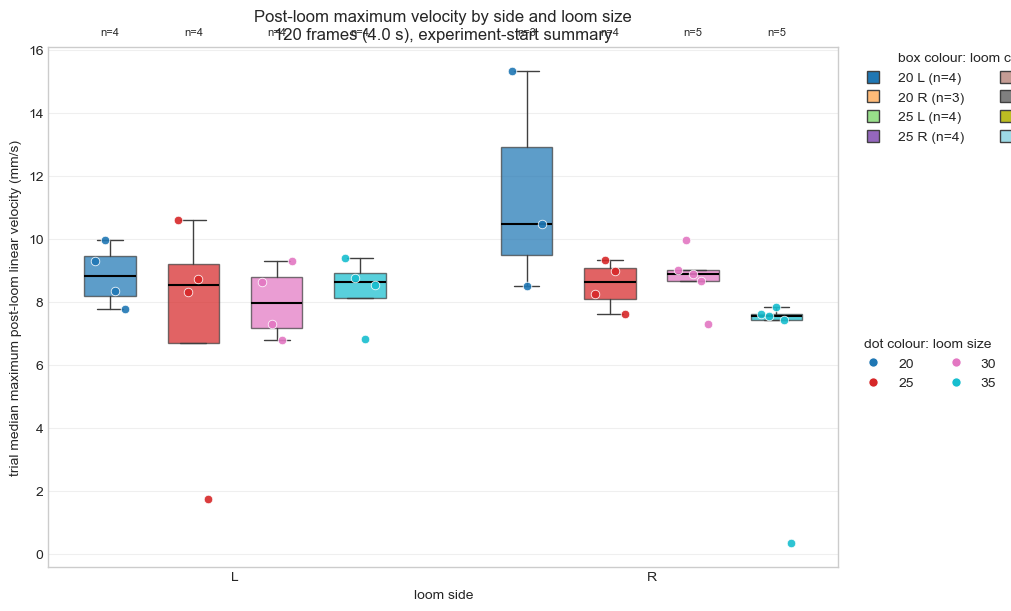

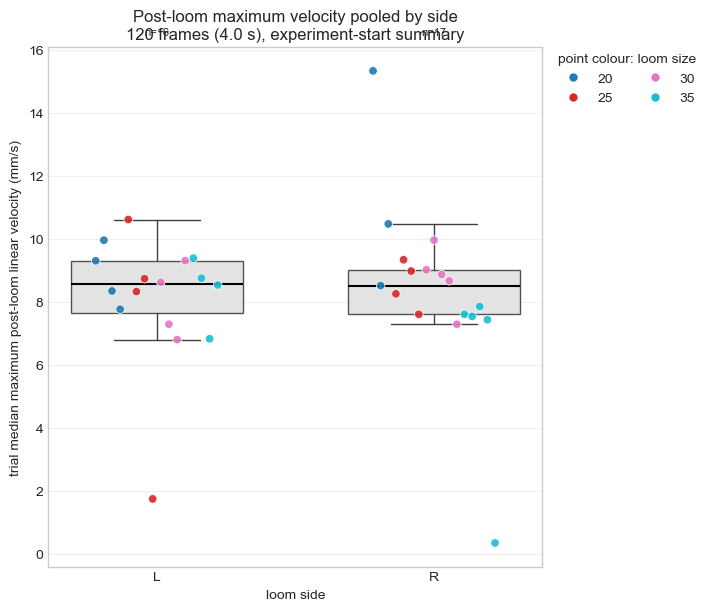

In [14]:
TRIAL_MAX_VELOCITY_BOXPLOT_VALUE_COLUMN = "trial_mean_max_linear_velocity_mm_s"
TRIAL_MAX_VELOCITY_BOXPLOT_VALUE_LABEL = "trial median maximum post-loom linear velocity (mm/s)"
TRIAL_MAX_VELOCITY_BOXPLOT_SIDES = ["L", "R"]


def plot_trial_max_velocity_boxplots(
    trial_summary,
    value_column=TRIAL_MAX_VELOCITY_BOXPLOT_VALUE_COLUMN,
    value_label=TRIAL_MAX_VELOCITY_BOXPLOT_VALUE_LABEL,
    sides=TRIAL_MAX_VELOCITY_BOXPLOT_SIDES,
    window_frames=TRIAL_MAX_VELOCITY_START_WINDOW_FRAMES,
    fps=VELOCITY_FPS,
):
    required_columns = {"loom_max_size", "side", "condition", value_column}
    missing_columns = sorted(required_columns.difference(trial_summary.columns))
    if missing_columns:
        raise ValueError(f"Missing required trial-summary columns: {missing_columns}")
    if not sides or len(set(sides)) != len(sides):
        raise ValueError("sides must contain unique side labels.")
    if fps <= 0:
        raise ValueError("fps must be greater than 0.")

    # Match the correlation plot's condition ordering and tab20 colour mapping.
    conditions = (
        trial_summary[["loom_max_size", "side", "condition"]]
        .drop_duplicates()
        .sort_values(["loom_max_size", "side"])
        .reset_index(drop=True)
    )
    if conditions.empty:
        raise ValueError("No trial conditions are available for the boxplots.")

    colors = plt.cm.tab20(np.linspace(0.02, 0.98, len(conditions)))
    condition_colors = dict(zip(conditions["condition"], colors))
    sizes = sorted(conditions.loc[conditions["side"].isin(sides), "loom_max_size"].unique())
    size_palette = plt.cm.tab10(np.linspace(0.05, 0.95, len(sizes)))
    size_colors = {int(size): color for size, color in zip(sizes, size_palette)}
    expected_conditions = {f"{int(size)} {side}" for size in sizes for side in sides}
    missing_conditions = sorted(expected_conditions.difference(condition_colors))
    if missing_conditions:
        raise ValueError(f"Missing L/R condition(s) for boxplots: {missing_conditions}")

    finite = trial_summary.loc[
        trial_summary["side"].isin(sides)
        & np.isfinite(trial_summary[value_column].to_numpy(dtype=float))
    ].copy()
    if finite.empty:
        raise ValueError("No finite trial-level maximum velocities are available.")

    box_kwargs = dict(
        widths=0.62,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        medianprops={"color": "black", "linewidth": 1.5},
        whiskerprops={"color": "0.25", "linewidth": 1.0},
        capprops={"color": "0.25", "linewidth": 1.0},
    )
    point_kwargs = dict(s=38, alpha=0.9, edgecolors="white", linewidths=0.6, zorder=3)

    # Layout 1: side groups with one coloured box for each loom size.
    condition_fig, condition_ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    group_centers = []
    n_sizes = len(sizes)
    group_spacing = n_sizes + 1
    for side_index, side in enumerate(sides):
        side_positions = []
        for size_index, size in enumerate(sizes):
            condition = f"{int(size)} {side}"
            subset = finite.loc[
                finite["side"].eq(side) & finite["loom_max_size"].eq(size)
            ].sort_values("trial")
            position = side_index * group_spacing + size_index
            side_positions.append(position)
            values = subset[value_column].to_numpy(dtype=float)
            condition_ax.boxplot(
                [values],
                positions=[position],
                boxprops={"facecolor": size_colors[int(size)], "edgecolor": "0.25", "alpha": 0.72},
                **box_kwargs,
            )
            jitter = np.linspace(-0.18, 0.18, len(values)) if len(values) > 1 else np.zeros(1)
            condition_ax.scatter(
                position + jitter,
                values,
                color=size_colors[int(size)],
                **point_kwargs,
            )
            condition_ax.text(
                position,
                1.02,
                f"n={len(values)}",
                transform=condition_ax.get_xaxis_transform(),
                ha="center",
                va="bottom",
                fontsize=8,
            )
        group_centers.append(np.mean(side_positions))

    condition_handles = [
        plt.Line2D(
            [],
            [],
            marker="s",
            linestyle="None",
            markerfacecolor=condition_colors[row.condition],
            markeredgecolor="0.25",
            markersize=8,
            label=f"{row.condition} (n={len(finite.loc[finite['condition'].eq(row.condition)])})",
        )
        for row in conditions.itertuples(index=False)
        if row.side in sides
    ]
    size_handles = [
        plt.Line2D(
            [],
            [],
            marker="o",
            linestyle="None",
            markerfacecolor=size_colors[int(size)],
            markeredgecolor="white",
            markersize=7,
            label=str(int(size)),
        )
        for size in sizes
    ]
    condition_ax.set_xticks(group_centers)
    condition_ax.set_xticklabels(sides)
    condition_ax.set_xlabel("loom side")
    condition_ax.set_ylabel(value_label)
    condition_ax.set_title(
        f"Post-loom maximum velocity by side and loom size\n"
        f"{window_frames} frames ({window_frames / fps:.1f} s), experiment-start summary"
    )
    condition_ax.grid(True, axis="y", alpha=0.3)
    condition_ax.grid(False, axis="x")
    condition_ax.set_axisbelow(True)
    condition_legend = condition_ax.legend(
        handles=condition_handles,
        title="box colour: loom condition",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        ncol=2,
    )
    condition_ax.add_artist(condition_legend)
    condition_ax.legend(
        handles=size_handles,
        title="dot colour: loom size",
        bbox_to_anchor=(1.02, 0.45),
        loc="upper left",
        borderaxespad=0,
        ncol=2,
    )

    # Layout 2: pooled side boxes with loom-size-coloured trial points.
    pooled_fig, pooled_ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    pooled_positions = {side: index for index, side in enumerate(sides)}
    pooled_ax.boxplot(
        [finite.loc[finite["side"].eq(side), value_column].to_numpy(dtype=float) for side in sides],
        positions=[pooled_positions[side] for side in sides],
        boxprops={"facecolor": "0.88", "edgecolor": "0.25", "alpha": 0.9},
        **box_kwargs,
    )
    for side in sides:
        subset = finite.loc[finite["side"].eq(side)].sort_values(["loom_max_size", "trial"])
        jitter = np.linspace(-0.22, 0.22, len(subset)) if len(subset) > 1 else np.zeros(1)
        pooled_ax.scatter(
            pooled_positions[side] + jitter,
            subset[value_column].to_numpy(dtype=float),
            color=[size_colors[int(size)] for size in subset["loom_max_size"]],
            **point_kwargs,
        )
        pooled_ax.text(
            pooled_positions[side],
            1.02,
            f"n={len(subset)}",
            transform=pooled_ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=8,
        )
    pooled_ax.set_xticks([pooled_positions[side] for side in sides])
    pooled_ax.set_xticklabels(sides)
    pooled_ax.set_xlabel("loom side")
    pooled_ax.set_ylabel(value_label)
    pooled_ax.set_title(
        f"Post-loom maximum velocity pooled by side\n"
        f"{window_frames} frames ({window_frames / fps:.1f} s), experiment-start summary"
    )
    pooled_ax.grid(True, axis="y", alpha=0.3)
    pooled_ax.grid(False, axis="x")
    pooled_ax.set_axisbelow(True)
    pooled_ax.legend(
        handles=size_handles,
        title="point colour: loom size",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        ncol=2,
    )

    return condition_fig, condition_ax, pooled_fig, pooled_ax, condition_colors


(
    trial_max_velocity_condition_boxplot_fig,
    trial_max_velocity_condition_boxplot_ax,
    trial_max_velocity_pooled_boxplot_fig,
    trial_max_velocity_pooled_boxplot_ax,
    trial_max_velocity_boxplot_colors,
) = plot_trial_max_velocity_boxplots(trial_max_velocity_start_summary)
plt.show()


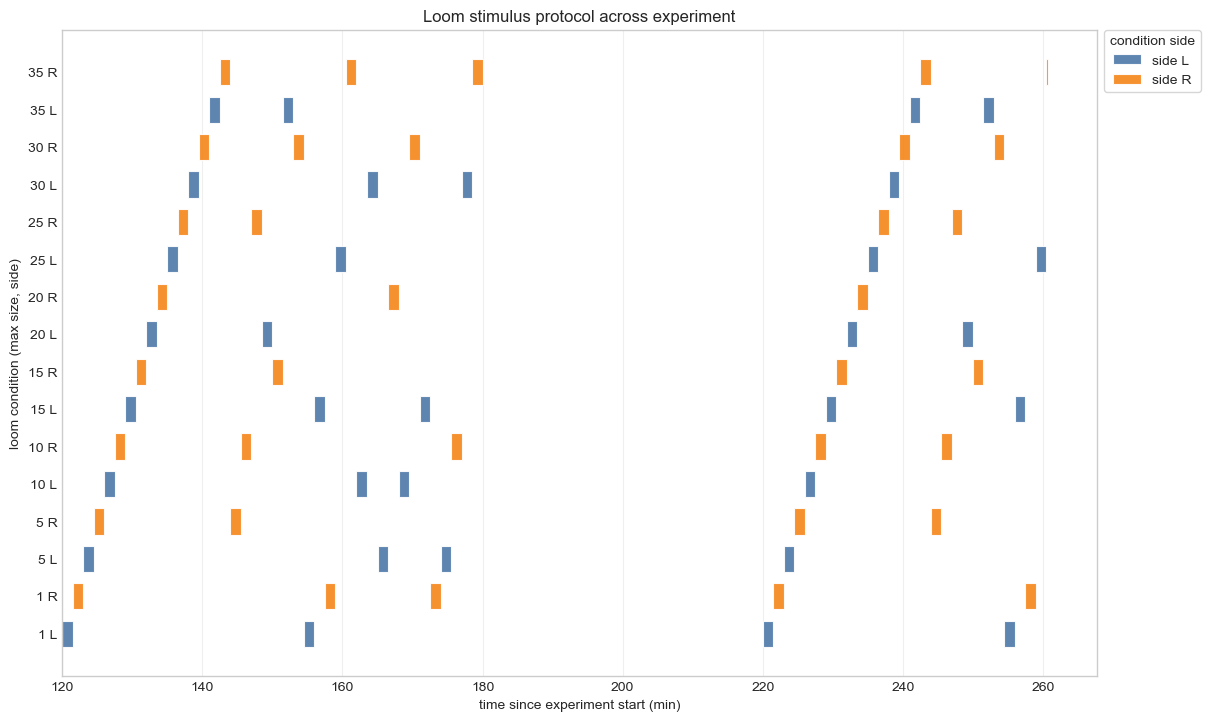

In [15]:
def plot_loom_protocol_timeline(trials_df, fps=VELOCITY_FPS):
    if trials_df.empty:
        raise ValueError("No CL trials available to plot.")

    timeline = trials_df.copy()
    timeline["start_min"] = timeline["block_start_frame"] / fps / 60
    timeline["duration_min"] = (timeline["block_end_frame"] - timeline["block_start_frame"] + 1) / fps / 60

    conditions = (
        timeline[["loom_max_size", "side"]]
        .drop_duplicates()
        .sort_values(["loom_max_size", "side"])
        .reset_index(drop=True)
    )
    conditions["condition_label"] = conditions.apply(
        lambda row: f"{int(row['loom_max_size'])} {row['side']}",
        axis=1,
    )
    condition_to_y = {
        (row.loom_max_size, row.side): idx
        for idx, row in conditions.iterrows()
    }
    timeline["y"] = timeline.apply(
        lambda row: condition_to_y[(row["loom_max_size"], row["side"])],
        axis=1,
    )

    side_colors = {"L": "#4c78a8", "R": "#f58518"}
    fig_height = max(4, 0.35 * len(conditions) + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_height), constrained_layout=True)

    for side, side_timeline in timeline.groupby("side", sort=True):
        ax.barh(
            side_timeline["y"],
            side_timeline["duration_min"],
            left=side_timeline["start_min"],
            height=0.7,
            color=side_colors.get(side, "#6f6f6f"),
            edgecolor="white",
            linewidth=0.8,
            alpha=0.9,
            label=f"side {side}",
        )

    ax.set_yticks(range(len(conditions)))
    ax.set_yticklabels(conditions["condition_label"])
    ax.set_xlabel("time since experiment start (min)")
    ax.set_ylabel("loom condition (max size, side)")
    ax.set_title("Loom stimulus protocol across experiment")
    ax.legend(title="condition side", loc="upper right", frameon=True, bbox_to_anchor=(1.1, 1), borderaxespad=0)
    ax.grid(True, axis="x", alpha=0.3)
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)

    return fig, ax, timeline.sort_values(["block_start_frame", "loom_max_size", "side"])


loom_protocol_fig, loom_protocol_ax, loom_protocol_timeline = plot_loom_protocol_timeline(trials)
plt.show()


## Timing and legacy hard-code audit

The legacy notebook hard-coded `CLstart = 624600`, `nStim = 16`, `cycles = 7`, and `clEpiLen = 2700`. That matches the positive-control dataset, not this primary 2026 recording. Here we derive the actual CL blocks from embedded episode labels, then use only the legacy fixed onset frame inside each derived block.

In [16]:
legacy_constants = pd.DataFrame(
    {
        "legacy_CLstart": [624600],
        "actual_first_CL_start": [trials["block_start_frame"].min()],
        "legacy_expected_CL_trials": [16 * 7],
        "actual_CL_trials": [len(trials)],
        "legacy_clEpiLen": [2700],
        "actual_unique_CL_lengths": [sorted(trials["n_frames"].unique())],
    }
)
display(legacy_constants)

onset_audit = trials.copy()
onset_audit["first_positive_size_in_block"] = onset_audit["onset_in_block"]
onset_audit["legacy_onset_in_block"] = LEGACY_ONSET_IN_BLOCK
display(
    onset_audit.groupby(["loom_max_size", "side"])
    .agg(trials=("trial", "count"), first_positive_size_in_block=("first_positive_size_in_block", "first"), legacy_onset_in_block=("legacy_onset_in_block", "first"))
    .reset_index()
)

display(blocks.groupby("category").agg(blocks=("block", "count"), frames=("n_frames", "sum")))

,legacy_CLstart,actual_first_CL_start,legacy_expected_CL_trials,actual_CL_trials,legacy_clEpiLen,actual_unique_CL_lengths
0,624600,216000,112,68,2700,"[352, 2700]"


,loom_max_size,side,trials,first_positive_size_in_block,legacy_onset_in_block
0,1,L,4,157,150
1,1,R,5,157,150
2,5,L,4,152,150
3,5,R,4,152,150
4,10,L,4,151,150
5,10,R,5,151,150
6,15,L,5,151,150
7,15,R,4,151,150
8,20,L,4,151,150
9,20,R,3,151,150


,blocks,frames
category,,
closed-loop loom,68,181252
moving trajectory,26,288000


## Legacy-aligned extraction

Legacy behavior reproduced here:

- fixed onset at epFrame 150 for every CL condition
- animal position at epFrame 150 is the origin
- animal and stimulus coordinates are both rotated by `-orientation_at_150 + pi/2`
- image y is not flipped before rotation
- no L/R mirroring is applied

In [17]:
snippets = extract_legacy_loom_snippets(
    animals,
    trials,
    stimulus,
    pre_frames=PRE_FRAMES,
    post_frames=POST_FRAMES,
    onset_in_block=LEGACY_ONSET_IN_BLOCK,
    n_animals=35,
)

legacy_metrics = legacy_loom_response_metrics(animals, trials)

label_sign = {"L": -1, "R": 1}
snippets["label_congruent_legacy_x"] = snippets["legacy_x"] * snippets["side"].map(label_sign)

snippets.shape, legacy_metrics.shape

((357000, 21), (2380, 11))

In [18]:
analysis_window = snippets.loc[snippets["relative_frame"].between(TRAJECTORY_START_FRAME, TRAJECTORY_END_FRAME)]

response_summary = (
    analysis_window.groupby(["loom_max_size", "side"])
    .agg(
        trials=("trial", "nunique"),
        animals=("animal", "nunique"),
        mean_center_dist_mm=("center_dist_mm", "mean"),
        mean_label_congruent_x=("label_congruent_legacy_x", "mean"),
        mean_step_dist=("step_dist", "mean"),
    )
    .reset_index()
)

legacy_metric_summary = (
    legacy_metrics.groupby(["loom_max_size", "side"])
    .agg(
        response_dist=("response_dist", "mean"),
        baseline_dist=("baseline_dist", "mean"),
        response_over_baseline=("response_over_baseline", "mean"),
        escape_fraction=("escape", "mean"),
    )
    .reset_index()
)

display(response_summary)
display(legacy_metric_summary)

,loom_max_size,side,trials,animals,mean_center_dist_mm,mean_label_congruent_x,mean_step_dist
0,1,L,4,35,3.968735,1.150693,0.916669
1,1,R,5,35,3.110075,0.349360,1.121443
2,5,L,4,35,4.656003,1.304913,1.073409
3,5,R,4,35,4.424674,-1.349214,1.022839
4,10,L,4,35,6.393321,-0.927362,1.388653
5,10,R,5,35,6.715917,-3.398795,1.388051
6,15,L,5,35,6.804493,-1.014595,1.467146
7,15,R,4,35,7.128676,-7.869524,1.504186
8,20,L,4,35,7.227590,1.956830,1.488516
9,20,R,3,35,8.408138,-7.718846,1.780663


,loom_max_size,side,response_dist,baseline_dist,response_over_baseline,escape_fraction
0,1,L,19.385242,26.225900,0.841999,0.028571
1,1,R,14.796788,20.706632,0.805143,0.040000
2,5,L,23.833193,25.045759,1.180225,0.114286
3,5,R,22.870105,26.185499,1.054840,0.107143
4,10,L,34.471539,25.807840,2.039293,0.235714
5,10,R,37.370846,24.817720,1.950939,0.302857
6,15,L,37.057157,25.213188,1.733623,0.291429
7,15,R,37.814665,27.154313,2.366547,0.278571
8,20,L,38.557271,26.788167,2.166337,0.328571
9,20,R,45.303292,24.369241,2.184291,0.428571


## Actual rotated trajectories

These plots show actual rotated animal positions for the largest three loom sizes, with frame samples superimposed as dots. The window is epFrame 151-199, matching the legacy plotting style. Points are filtered by each trial-animal's legacy `response_over_baseline` metric; the default lower threshold is `> 2`, matching the escape classification rule. Edit the min/max filter values at the top of the next cell; set either bound to `None` to disable that side of the range. The stimulus is not rotated or plotted here; the VR setup already placed it in egocentric coordinates.

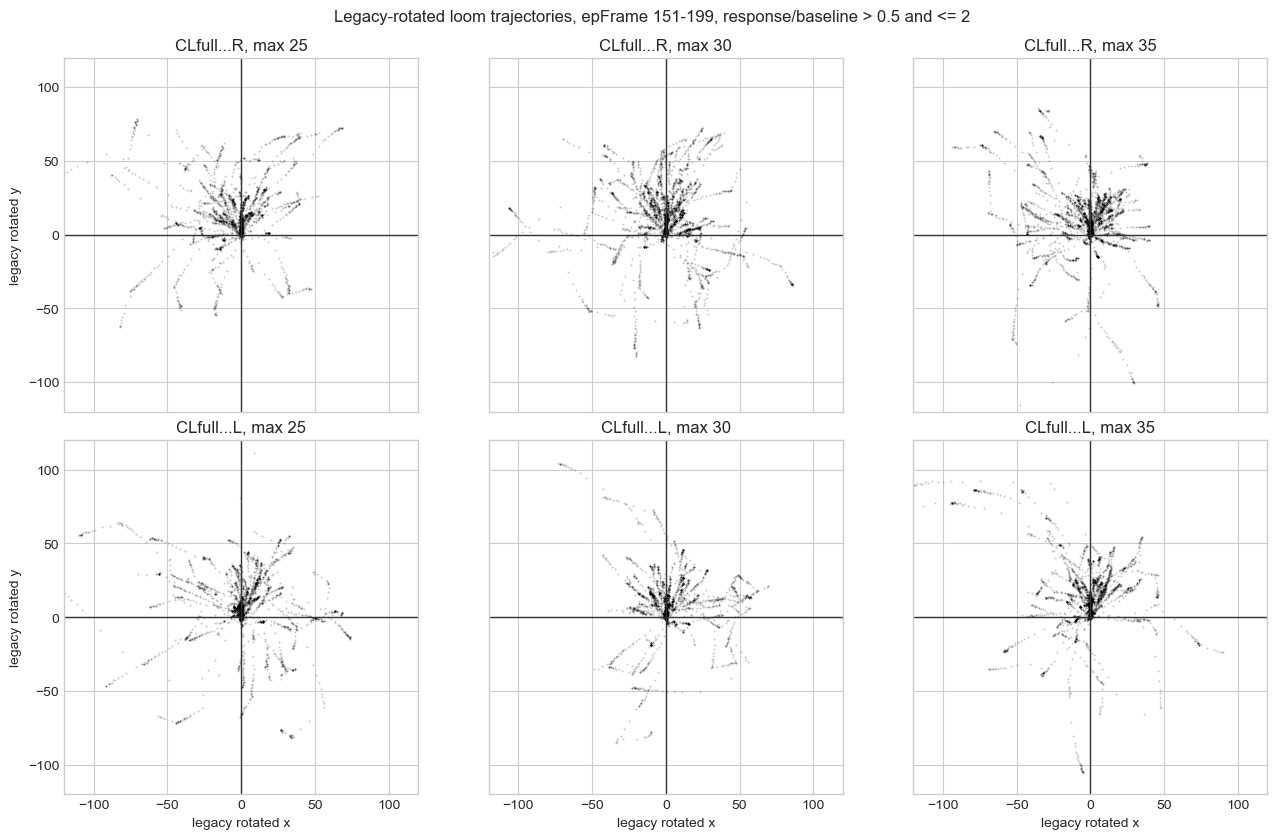

In [19]:
# Set either bound to None to disable that side of the response filter.
TRAJECTORY_RESPONSE_OVER_BASELINE_MIN = 0.5
TRAJECTORY_RESPONSE_OVER_BASELINE_MAX = 2

largest_sizes = sorted(trials["loom_max_size"].unique())[-3:]
trajectory_response_metrics = legacy_metrics[["trial", "animal", "response_over_baseline"]]

plot_points = snippets.loc[
    snippets["relative_frame"].between(TRAJECTORY_START_FRAME, TRAJECTORY_END_FRAME)
    & snippets["loom_max_size"].isin(largest_sizes)
].merge(trajectory_response_metrics, on=["trial", "animal"], how="left")

trajectory_response_mask = pd.Series(True, index=plot_points.index)
trajectory_response_filter_parts = []
if TRAJECTORY_RESPONSE_OVER_BASELINE_MIN is not None:
    trajectory_response_mask &= plot_points["response_over_baseline"].gt(TRAJECTORY_RESPONSE_OVER_BASELINE_MIN)
    trajectory_response_filter_parts.append(f"> {TRAJECTORY_RESPONSE_OVER_BASELINE_MIN:g}")
if TRAJECTORY_RESPONSE_OVER_BASELINE_MAX is not None:
    trajectory_response_mask &= plot_points["response_over_baseline"].le(TRAJECTORY_RESPONSE_OVER_BASELINE_MAX)
    trajectory_response_filter_parts.append(f"<= {TRAJECTORY_RESPONSE_OVER_BASELINE_MAX:g}")
plot_points = plot_points.loc[trajectory_response_mask]
trajectory_response_filter_label = (
    "all response/baseline values"
    if not trajectory_response_filter_parts
    else "response/baseline " + " and ".join(trajectory_response_filter_parts)
)

fig, axes = plt.subplots(2, len(largest_sizes), figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True)
side_order = [("R", "CLfull...R"), ("L", "CLfull...L")]

for row, (side, side_title) in enumerate(side_order):
    for col, size in enumerate(largest_sizes):
        ax = axes[row, col]
        subset = plot_points.loc[plot_points["side"].eq(side) & plot_points["loom_max_size"].eq(size)]
        ax.scatter(subset["legacy_x"], subset["legacy_y"], s=2, alpha=0.22, color="black", linewidths=0)
        ax.axhline(0, color="0.2", lw=1)
        ax.axvline(0, color="0.2", lw=1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-120, 120)
        ax.set_ylim(-120, 120)
        ax.set_title(f"{side_title}, max {size}")
        if col == 0:
            ax.set_ylabel("legacy rotated y")
        if row == 1:
            ax.set_xlabel("legacy rotated x")

fig.suptitle(
    f"Legacy-rotated loom trajectories, epFrame 151-199, {trajectory_response_filter_label}",
    y=1.03,
)
plt.show()

## Legacy distance traces and response metrics

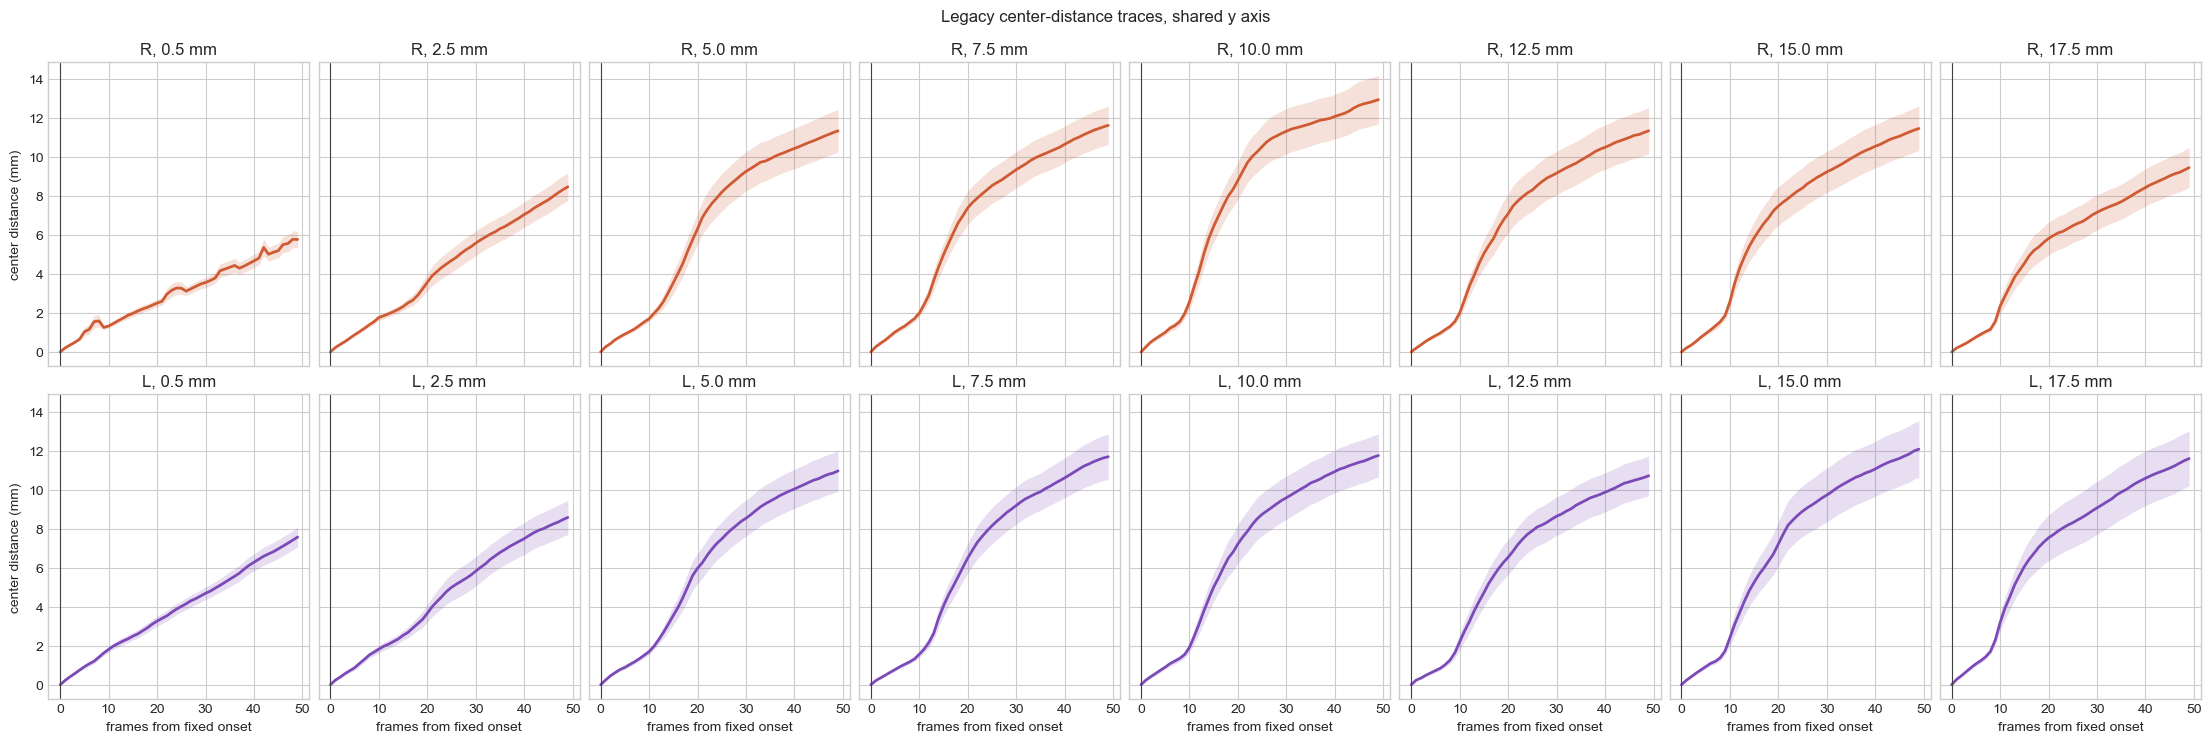

In [20]:
animal_condition_traces = snippets.groupby(
    ["loom_max_size", "side", "animal", "relative_frame"], as_index=False
)[["center_dist_mm", "label_congruent_legacy_x"]].mean()

group_keys = ["loom_max_size", "side", "relative_frame"]
condition_mean = animal_condition_traces.groupby(group_keys, as_index=False)[["center_dist_mm", "label_congruent_legacy_x"]].mean()
condition_sem = (
    animal_condition_traces.groupby(group_keys)[["center_dist_mm", "label_congruent_legacy_x"]]
    .sem()
    .reset_index()
    .rename(columns={"center_dist_mm": "center_dist_mm_sem", "label_congruent_legacy_x": "label_congruent_legacy_x_sem"})
)
condition_stats = condition_mean.rename(columns={"center_dist_mm": "center_dist_mm_mean", "label_congruent_legacy_x": "label_congruent_legacy_x_mean"}).merge(condition_sem, on=group_keys)

all_sizes = sorted(trials["loom_max_size"].unique())
fig, axes = plt.subplots(2, len(all_sizes), figsize=(22, 7), sharex=True, sharey=True, constrained_layout=True)
side_colors = {"L": "#7b4ab8", "R": "#cf5a33"}

for row, side in enumerate(["R", "L"]):
    for col, size in enumerate(all_sizes):
        ax = axes[row, col]
        stats = condition_stats.loc[condition_stats["side"].eq(side) & condition_stats["loom_max_size"].eq(size) & condition_stats["relative_frame"].between(0, 49)]
        ax.plot(stats["relative_frame"], stats["center_dist_mm_mean"], color=side_colors[side], lw=2)
        ax.fill_between(stats["relative_frame"], stats["center_dist_mm_mean"] - stats["center_dist_mm_sem"], stats["center_dist_mm_mean"] + stats["center_dist_mm_sem"], color=side_colors[side], alpha=0.18, lw=0)
        ax.axvline(0, color="0.25", lw=0.8)
        ax.set_title(f"{side}, {size / 2:.1f} mm")
        if col == 0:
            ax.set_ylabel("center distance (mm)")
        if row == 1:
            ax.set_xlabel("frames from fixed onset")

fig.suptitle("Legacy center-distance traces, shared y axis", y=1.04)
plt.show()

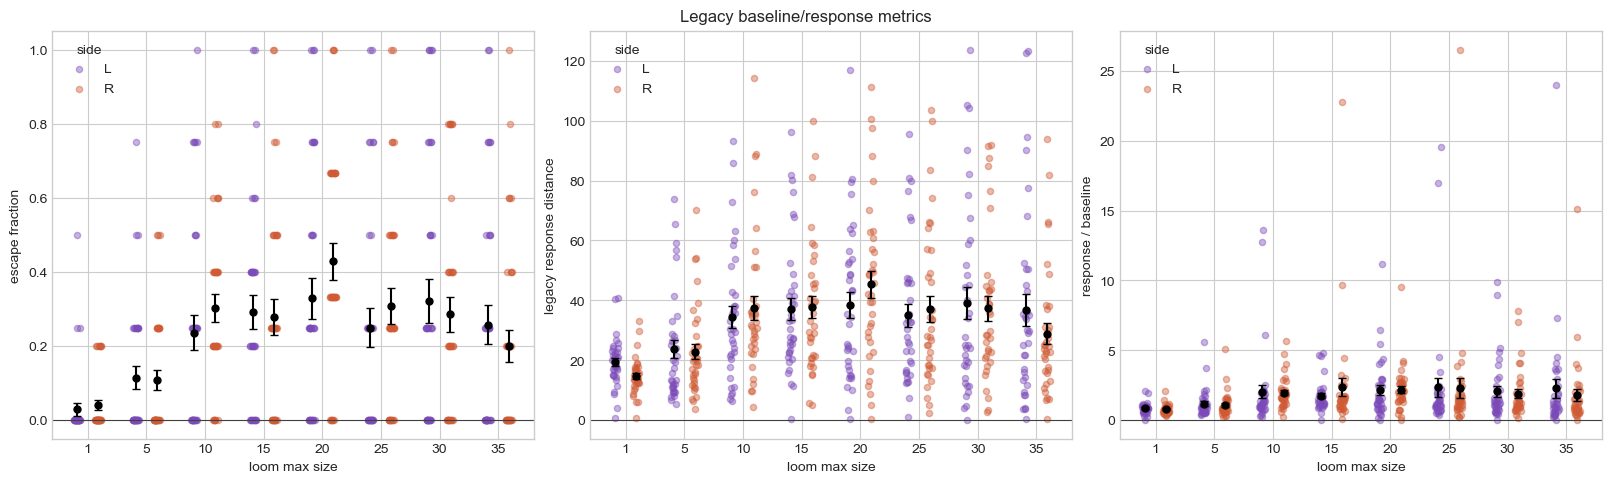

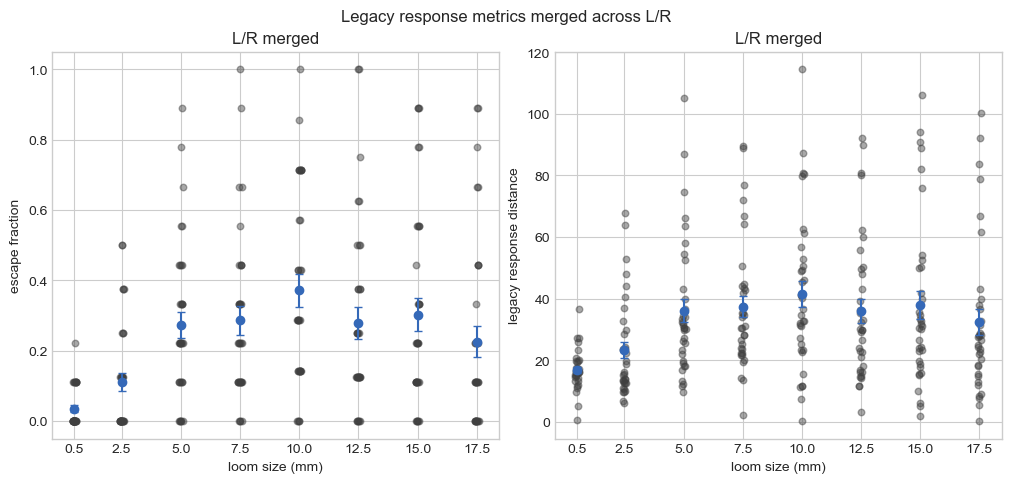

In [ ]:
# Each row of legacy_metrics is one trial x animal measurement computed by
# legacy_loom_response_metrics. The underlying distances use the original
# raw animal x/y coordinates, not the rotated trajectory coordinates plotted
# above. For each trial and animal, baseline_dist is the displacement from
# CL block frame 100 to 140, and response_dist is the displacement from
# CL block frame 149 to 180. The response_over_baseline metric is
# response_dist / baseline_dist; escape is True when that ratio is > 2.
#
# Average across repeated trials first, so each dot in the first figure is
# one animal's mean value for one loom size and one L/R side. This keeps
# animals, rather than trials, as the plotted replicate unit.
animal_escape = legacy_metrics.groupby(["loom_max_size", "side", "animal"], as_index=False)[["escape", "response_dist", "response_over_baseline"]].mean()

# Figure 1: side-resolved legacy metrics by maximum loom size.
# - escape fraction: fraction of repeated trials for that animal/side/size
#   where response_over_baseline > 2. Values range from 0 to 1.
# - legacy response distance: mean raw x/y displacement during the response
#   window, in the animal-file coordinate units.
# - response / baseline: mean ratio of response-window displacement to the
#   baseline-window displacement. Values > 1 mean more movement during the
#   response window than during baseline; the escape threshold is > 2.
# Colored dots are individual animals; black markers show the across-animalc
# mean for each side/size, with SEM error bars.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
x_base = np.arange(len(all_sizes))
offsets = {"L": -0.18, "R": 0.18}

for ax, metric, ylabel in [
    (axes[0], "escape", "escape fraction"),
    (axes[1], "response_dist", "legacy response distance"),
    (axes[2], "response_over_baseline", "response / baseline"),
]:
    for side in ["L", "R"]:
        subset = animal_escape.loc[animal_escape["side"].eq(side)]
        for i, size in enumerate(all_sizes):
            values = subset.loc[subset["loom_max_size"].eq(size), metric].to_numpy()
            jitter = np.linspace(-0.05, 0.05, len(values)) if len(values) else []
            ax.scatter(np.full(len(values), x_base[i] + offsets[side]) + jitter, values, color=side_colors[side], alpha=0.42, s=20, label=side if i == 0 else None)
            ax.errorbar(x_base[i] + offsets[side], np.nanmean(values), yerr=np.nanstd(values) / np.sqrt(np.isfinite(values).sum()), color="black", marker="o", capsize=3, ms=5)
    ax.axhline(0, color="0.25", lw=0.8)
    ax.set_xticks(x_base)
    ax.set_xticklabels([str(size) for size in all_sizes])
    ax.set_xlabel("loom max size")
    ax.set_ylabel(ylabel)
    ax.legend(title="side")

fig.suptitle("Legacy baseline/response metrics", y=1.04)
plt.show()

# Figure 2: same legacy escape and response-distance metrics after merging
# L and R trials. Each dot is one animal's mean across both sides for a given
# loom size. The x axis is converted from the stored maximum loom size to the
# plotted physical size using size / 2, matching the mm labels used above.
# This merged view intentionally drops response_over_baseline and focuses on
# the two main legacy summary metrics: escape fraction and response distance.
merged_escape = legacy_metrics.groupby(["loom_max_size", "animal"], as_index=False)[["escape", "response_dist"]].mean()
size_x = np.array(all_sizes) / 2.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

for ax, metric, ylabel in [
    (axes[0], "escape", "escape fraction"),
    (axes[1], "response_dist", "legacy response distance"),
]:
    for i, size in enumerate(all_sizes):
        values = merged_escape.loc[merged_escape["loom_max_size"].eq(size), metric].to_numpy()
        jitter = np.linspace(-0.08, 0.08, len(values)) if len(values) else []
        ax.scatter(np.full(len(values), size_x[i]) + jitter, values, color="0.25", alpha=0.45, s=22)
        ax.errorbar(size_x[i], np.nanmean(values), yerr=np.nanstd(values) / np.sqrt(np.isfinite(values).sum()), color="#3569b8", marker="o", capsize=3, ms=6)
    ax.set_xlabel("loom size (mm)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(size_x)
    ax.set_title("L/R merged")

axes[0].set_ylim(-0.05, 1.05)
fig.suptitle("Legacy response metrics merged across L/R", y=1.04)
plt.show()